# 09 - Visualization

So far, we have imported raw data and cleaned it into a table that is suitable for analysis. A table of numbers is where the work happens; it is almost never where the work *ends*. This session is about the other half - turning a table into a figure somebody else can read.

This notebooks covers the following topics:

1. Figures and axes - `fig`, `ax`, and why the one-liner runs out
2. Getting the table into shape - long and wide, `pivot` and `melt` 
3. Four questions, four charts - line, bar, scatter, histogram 
4. Making a chart readable - labels, limits, scales, ticks, reference lines 
5. Several panels in one figure - `plt.subplots` with more than one set of axes
6. A function that draws a figure - the same plot for any region you hand it
7. Saving a figure - `savefig`, and what a figure is for



Two things are worth saying before we start.

**A chart is not a decoration.** Every figure in this notebook is an argument about the data, and the same table supports several different arguments depending on what you draw. That is not a flaw in plotting; it is the reason the choices are worth teaching.

**A chart fails quietly.** A wrong number often looks wrong. A wrong figure looks exactly like a right one - it just draws a line through a gap, or averages seven things that should not have been averaged.

As always, we start by importing what we need and loading our own data.

`matplotlib` is the plotting library. Almost everything we want lives in one of its modules, `matplotlib.pyplot`, and it is always imported under the name `plt` - that abbreviation is as universal as `pd` for pandas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

And here is last week's work in one cell. Nothing in it is new: read both files, tidy the lookup file's column name, merge on the key that matches, check the shape of the merge, drop the aggregates, and add emissions per person. That was a session; now it is the setup.

In [3]:
co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

info = info.rename(columns={"incomeLevel": "income_level"})

panel = co2.merge(
    info[["code", "region", "income_level"]],
    on="code",
    how="left",
    validate="many_to_one",
)

panel = panel[panel["region"] != "Aggregates"]
panel = panel.dropna(subset=["co2_total"])
panel["co2_pc"] = panel["co2_total"] * 1_000_000 / panel["population"]

print("rows:     ", len(panel))
print("countries:", panel["code"].nunique())
print("years:    ", panel["year"].min(), "-", panel["year"].max())

panel.head()

rows:      4872
countries: 203
years:     2000 - 2023


,country,code,year,co2_total,population,urban,gdp_pc,electricity,agriculture,nat_resources,renew_energy,region,income_level,co2_pc
0,Afghanistan,AFG,2000,1.0093,20130327,18.558,174.93,4.4,57.946,NaN,45.0,"Middle East, North Africa, Afghanistan & Pakistan",Low income,0.050138
1,Afghanistan,AFG,2001,0.9402,20284307,18.741,138.71,9.3,57.947,NaN,45.6,"Middle East, North Africa, Afghanistan & Pakistan",Low income,0.046351
2,Afghanistan,AFG,2002,0.9388,21378117,18.941,178.95,14.1,57.940,1.2761,37.8,"Middle East, North Africa, Afghanistan & Pakistan",Low income,0.043914
3,Afghanistan,AFG,2003,1.0172,22733049,19.160,198.87,19.0,58.084,0.7313,36.7,"Middle East, North Africa, Afghanistan & Pakistan",Low income,0.044745
4,Afghanistan,AFG,2004,0.9024,23560654,19.399,221.76,23.8,58.151,0.4589,44.2,"Middle East, North Africa, Afghanistan & Pakistan",Low income,0.038301


203 countries, 24 years each, no aggregates. Everything in this notebook is drawn from that table.

## 1. Figures and axes



Last week ended with a chart, and it took one line:

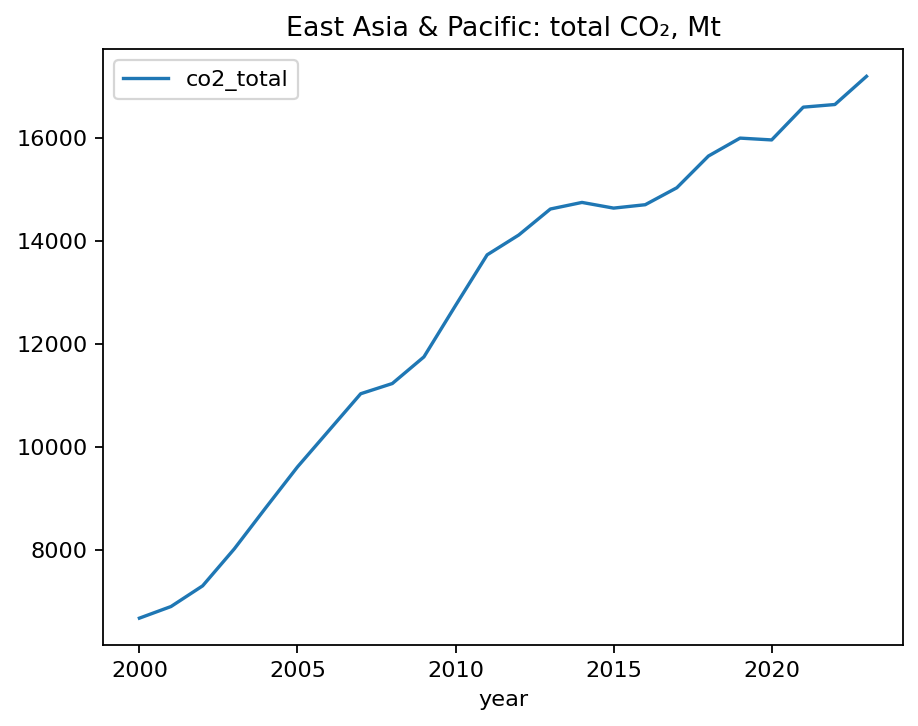

In [4]:
east_asia = panel[panel["region"] == "East Asia & Pacific"]
yearly = east_asia.groupby("year")["co2_total"].sum().reset_index()

yearly.plot(x="year", y="co2_total", title="East Asia & Pacific: total CO₂, Mt");

`.plot()` is a pandas method, and for a quick look at a column it is unbeatable. It also runs out quickly. The y-axis has no label and no units. The legend says `co2_total`, which is a column name rather than English. And the moment you want two of these side by side, or a line drawn across one of them, there is nowhere to say *which* picture you mean.

So we go one level down, to the library pandas is calling.

### The two objects

matplotlib gives you two things, and every plotting instruction is addressed to one of them.

| Object | What it is | What you ask it for |
|---|---|---|
| `fig` | the whole picture - the sheet of paper | how big it is, a title over everything, saving it to disk |
| `ax` | one set of axes drawn on that sheet - the box the data goes in | the data itself, axis labels, limits, ticks, the legend |

You make both at once with `plt.subplots()`, which returns them as a pair:

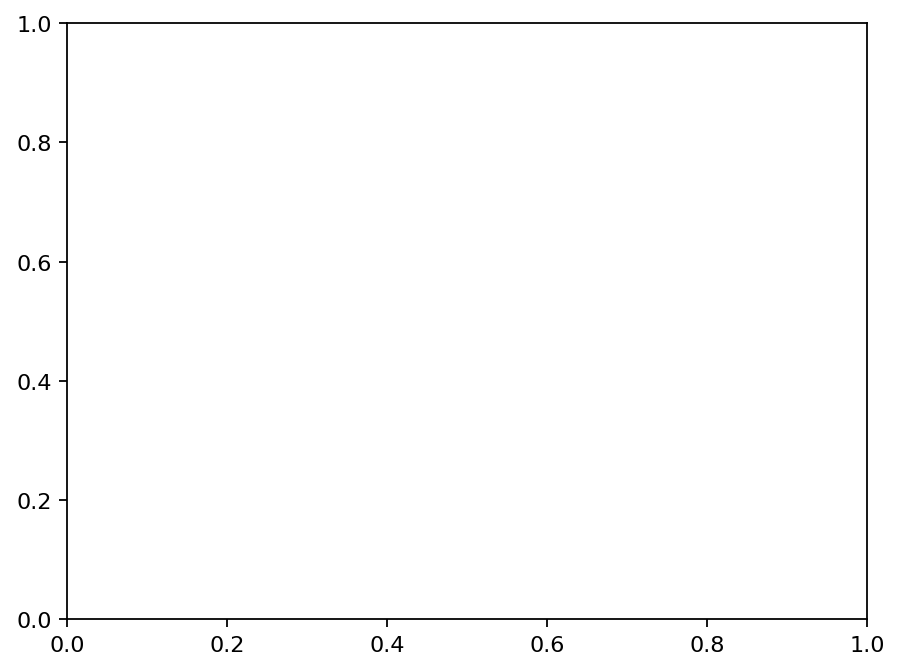

In [13]:
fig, ax = plt.subplots()

plt.show()

An empty figure with one empty set of axes on it - matplotlib draws it immediately, which is why you can see it.

Now put something in it. The methods are named for what they draw: `ax.plot` draws lines, and the ones that set text on the axes are `ax.set_xlabel`, `ax.set_ylabel` and `ax.set_title`. Each takes the data or the string you want.

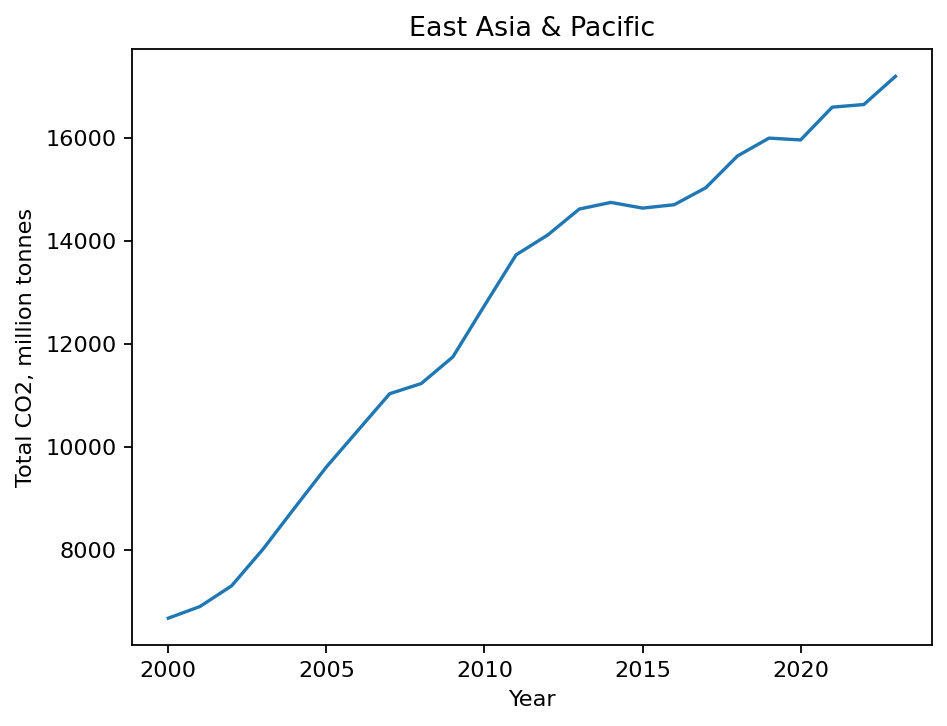

In [ ]:
fig, ax = plt.subplots()

ax.plot(yearly["year"], yearly["co2_total"])

ax.set_xlabel("Year")
ax.set_ylabel("Total CO2, million tonnes")
ax.set_title("East Asia & Pacific")

plt.show()

Six lines instead of one, and every one of them is a decision you can now change.

### Size

`plt.subplots` takes `figsize`, a pair of numbers giving width and height **in inches**. The default is 6.4 by 4.8, which is fine for a quick look and usually too small for anything with a legend.

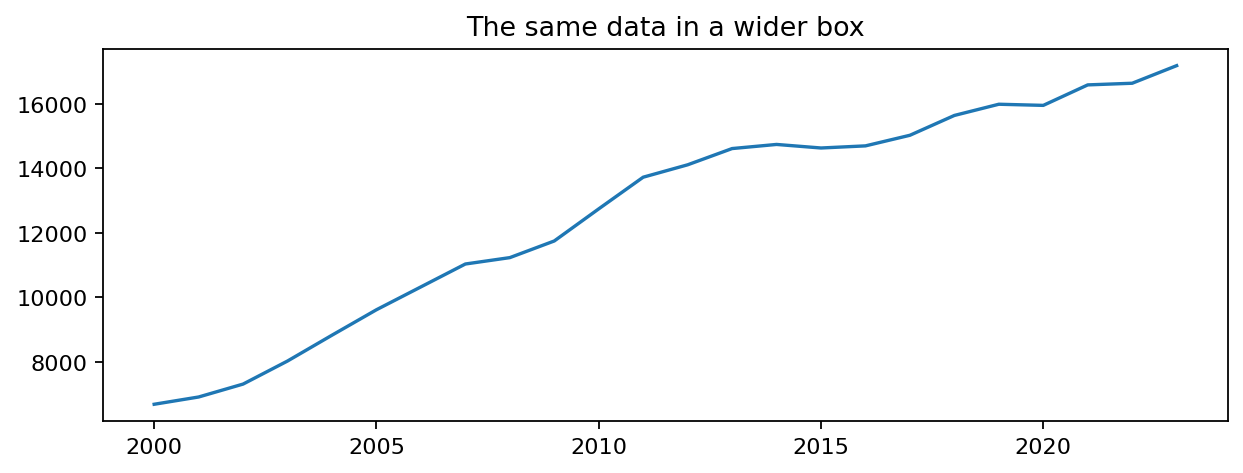

In [18]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(yearly["year"], yearly["co2_total"])
ax.set_title("The same data in a wider box")

plt.show()

### You can have both

`df.plot()` is not a different system - it is a shortcut that builds a `fig` and an `ax` for you and then hands the `ax` back. So you can combine matplotlib with plotting functions from pandas:

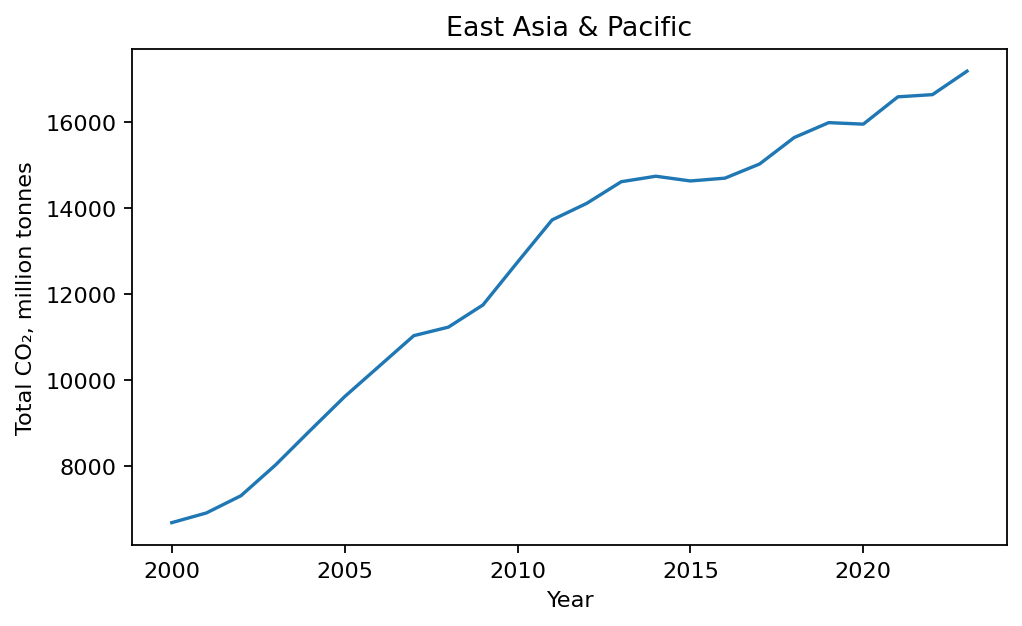

In [ ]:
fig, ax = plt.subplots()

yearly.plot(x="year", y="co2_total", ax=ax, legend=False, figsize=(7, 4))

ax.set_xlabel("Year")
ax.set_ylabel("Total CO₂, million tonnes")
ax.set_title("East Asia & Pacific")

plt.show()

## 2. Getting the table into shape

Here is the first real decision, and it is not a plotting decision at all - it is about the table.

We want **one line per region**, all seven on one chart. Start from last week's result: group by region and year, and total the emissions.

In [21]:
regional = panel.groupby(["region", "year"])["co2_total"].sum().reset_index()

print(regional.shape)
regional.head(4).round(1)

(168, 3)


,region,year,co2_total
0,East Asia & Pacific,2000,6681.3
1,East Asia & Pacific,2001,6907.1
2,East Asia & Pacific,2002,7308.2
3,East Asia & Pacific,2003,8024.2


168 rows - seven regions times 24 years - and three columns. Every row is one region in one year, and the thing being measured is named by the *value* in the `region` column rather than by which column it sits in.

That shape has a name: **long**. It is what `groupby` gives you, and it is what almost every pandas operation wants.

The other shape is **wide**: one row per year, one *column* per region, and the emissions figures in the body of the table.

| | Long | Wide |
|---|---|---|
| One row is | one region in one year | one year |
| Regions are | values in a column | column names |
| Adding an eighth region | adds 24 rows | adds a column |
| Good for | `groupby`, `merge`, filtering | reading, and plotting one line per column |

Neither is more correct. They hold identical information, and you move between them constantly.

### `pivot` goes long to wide


`pivot` takes three arguments: 
- `index` is the column whose values become the rows
- `columns` is the column whose values become the new column names
-  `values` is the column that fills the body

In [ ]:
wide = regional.pivot(index="year", columns="region", values="co2_total")

print(wide.shape)
wide.head()

(24, 7)


region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,"Middle East, North Africa, Afghanistan & Pakistan",North America,South Asia,Sub-Saharan Africa
year,,,,,,,
2000,6681.3359,6906.3139,1351.0142,1516.6216,6472.0194,1039.7875,571.5449
2001,6907.0830,6949.6742,1352.6127,1592.0497,6412.1537,1061.6542,592.2733
2002,7308.1604,6946.8150,1353.8011,1644.8627,6280.9583,1101.4619,596.0773
2003,8024.1583,7189.9360,1385.8478,1704.5605,6366.7770,1136.3235,631.9437
2004,8825.6635,7206.7729,1449.5072,1809.0303,6439.9085,1223.4122,667.4089


24 rows by 7 columns, and the year has become the index. Note that the columns come out in alphabetical order - `pivot` sorts them.

### `melt` goes wide to long

`melt` is the inverse. 

`id_vars` names the columns to keep as they are; everything else is collapsed into two new columns, whose names you give with `var_name` and `value_name`.

In [26]:
back = wide.reset_index().melt(
    id_vars="year",
    var_name="region",
    value_name="co2_total",
)

print(back.shape)
back.head().round(1)

(168, 3)


,year,region,co2_total
0,2000,East Asia & Pacific,6681.3
1,2001,East Asia & Pacific,6907.1
2,2002,East Asia & Pacific,7308.2
3,2003,East Asia & Pacific,8024.2
4,2004,East Asia & Pacific,8825.7


168 rows again. `reset_index()` first because `year` is the index of `wide` and `melt` works on columns.

### Aggregate before you pivot

`pivot` cannot invent an answer. If more than one row would land in the same cell, it stops:

In [28]:
# ValueError
panel.pivot(index="year", columns="region", values="co2_total")

ValueError: Index contains duplicate entries, cannot reshape

`Index contains duplicate entries, cannot reshape`. Of course: `panel` has 37 East Asian countries in 2023, so the cell at row 2023, column "East Asia & Pacific" has 37 candidates and `pivot` will not choose between them.

This is a **good** error. It is refusing to guess. The fix is to say what you meant - group and aggregate first, which is exactly what `regional` is - and only then reshape.

### So which shape do you want?

For a chart with one line per group, either works.

Notice that `groupby` on its own, with no aggregation attached, is iterable: each turn of the loop gives you the group's name and the rows belonging to it. That is the split of split-apply-combine, with the apply left to you.

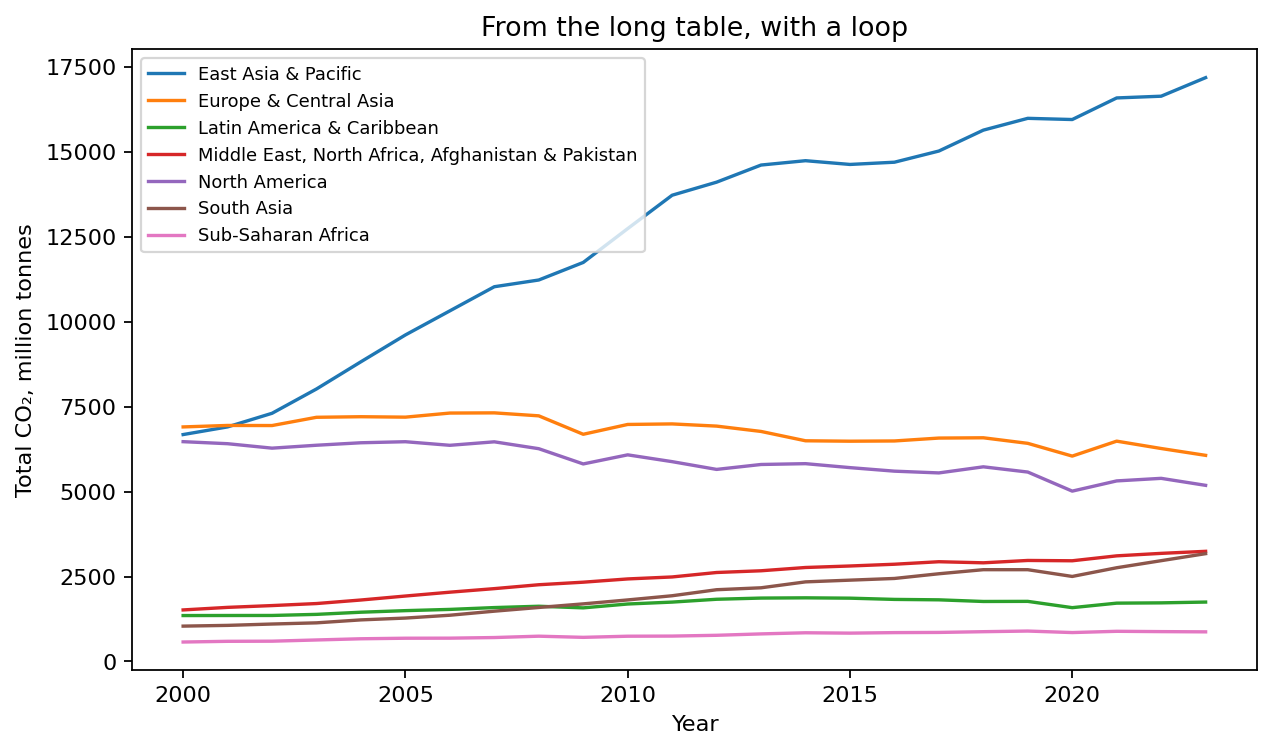

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

# Long: loop over the groups, one call to ax.plot per group.
for name, group in regional.groupby("region"):
    ax.plot(group["year"], group["co2_total"], label=name)

ax.set_xlabel("Year")
ax.set_ylabel("Total CO2, million tonnes")
ax.legend(fontsize=8)
ax.set_title("From the long table, with a loop")

plt.show()

Now the same figure from the wide table:

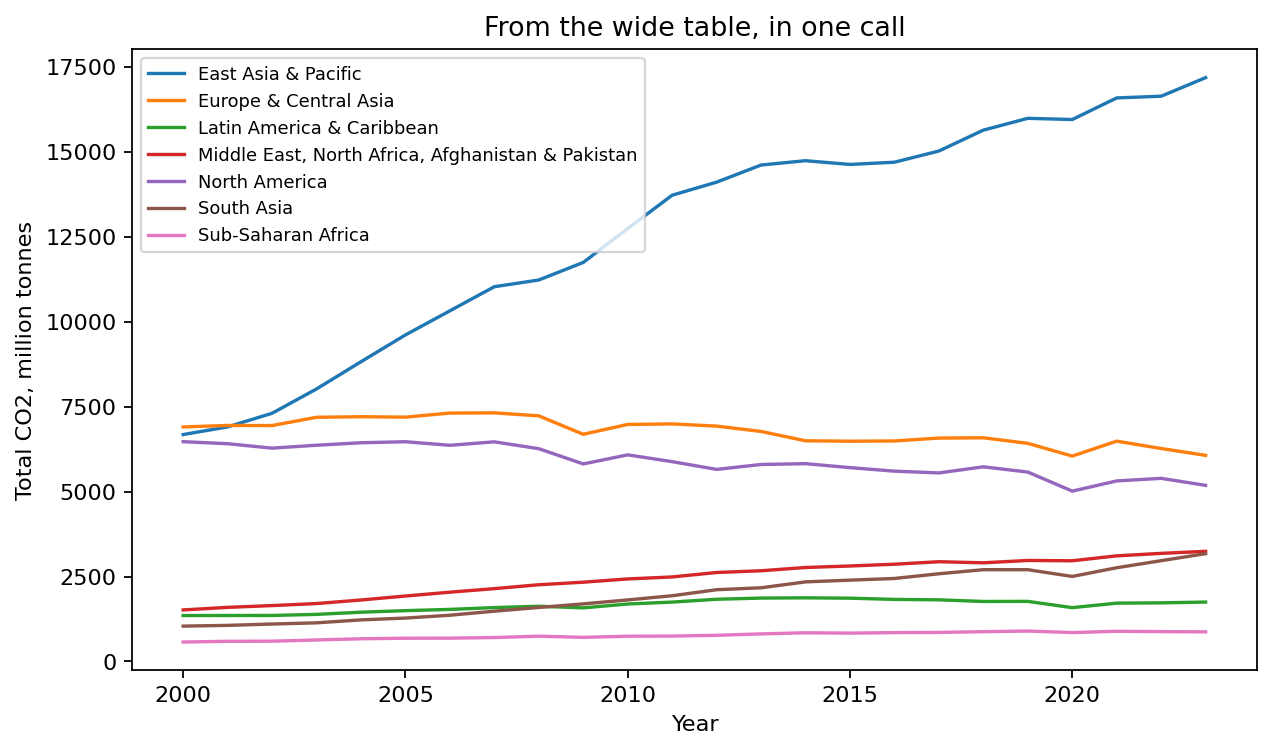

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

wide.plot(ax=ax)

ax.set_xlabel("Year")
ax.set_ylabel("Total CO2, million tonnes")
ax.legend(fontsize=8)
ax.set_title("From the wide table, in one call")

plt.show()

One line of drawing instead of three, because pandas reads the shape of the table as the shape of the chart: **one column, one line, and the column name is the label.** `ax=ax` tells it to draw on the axes we already made rather than making its own.

The rule that follows:
- **Long for computing.** `groupby`, `merge`, filtering and every check from last week are easier, and sometimes only possible, on a long table.
- **Wide for reading, and for a one-call chart.** A human comparing four regions in 2010 reads the wide table far faster, and `wide.plot()` needs no loop.

Keep the long version, and reshape at the last minute, for the chart.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">

<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Reshape a table for plotting, and draw it. In a single cell, total <code>co2_total</code> by <code>income_level</code> and <code>year</code>, turn the result into a wide table with one row per year and one column per income level, and draw it with one line per income level, with axis labels and a legend. Print the shape of the long table and of the wide one as you go.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")
info = info.rename(columns={"incomeLevel": "income_level"})

df = co2.merge(info[["code", "region", "income_level"]], on="code", how="left")
df = df[df["region"] != "Aggregates"]</code></pre>

</div>

## 3. Four questions, four charts

There are hundreds of chart types and you will use four of them. What separates them is not what they look like but **what question they answer**, so that is how they are worth learning.

| The question you are asking | The chart | The method |
|---|---|---|
| How did something change over time? | line | `ax.plot` |
| How do a handful of categories compare? | bar | `ax.bar`, `ax.barh` |
| Are these two variables related? | scatter | `ax.scatter` |
| How is one variable spread out? | histogram | `ax.hist` |

Pick the chart from the question, not from the table. A table of seven regions in 2023 will happily produce all four, and three of them will be nonsense.

### 3.1 Change over time: `ax.plot`

We drew this one in section 2, so here is the thing about it that matters instead.

A line chart draws a straight segment between each pair of points you give it, **and says nothing at all about what happened in between.** That is fine when the points are a year apart and the world is smooth. It is a disaster when some of the points are missing and you removed them before plotting.

Here is a real case from the file we have been using all along. `nat_resources` is the value of a country's natural resources - oil, gas, minerals - as a percentage of its GDP, and Timor-Leste's oil revenues arrived partway through the period.

In [42]:
timor = panel[panel["country"] == "Timor-Leste"].sort_values("year")
rents = timor.set_index("year")["nat_resources"]

print("years with no figure:", list(rents[rents.isna()].index))
rents.round(2)

years with no figure: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2022, 2023]


year
2000     0.40
2001     0.35
2002     0.39
2003     0.52
2004      NaN
2005      NaN
2006      NaN
2007      NaN
2008      NaN
2009      NaN
2010      NaN
2011      NaN
2012      NaN
2013      NaN
2014      NaN
2015    79.43
2016    44.56
2017    44.87
2018    62.77
2019    44.90
2020    34.39
2021    34.73
2022      NaN
2023      NaN
Name: nat_resources, dtype: float64

Thirteen of the 24 years have no figure at all, and eleven of those are one unbroken run in the middle. Now the thing people often do: drop the missing rows and plot what is left.

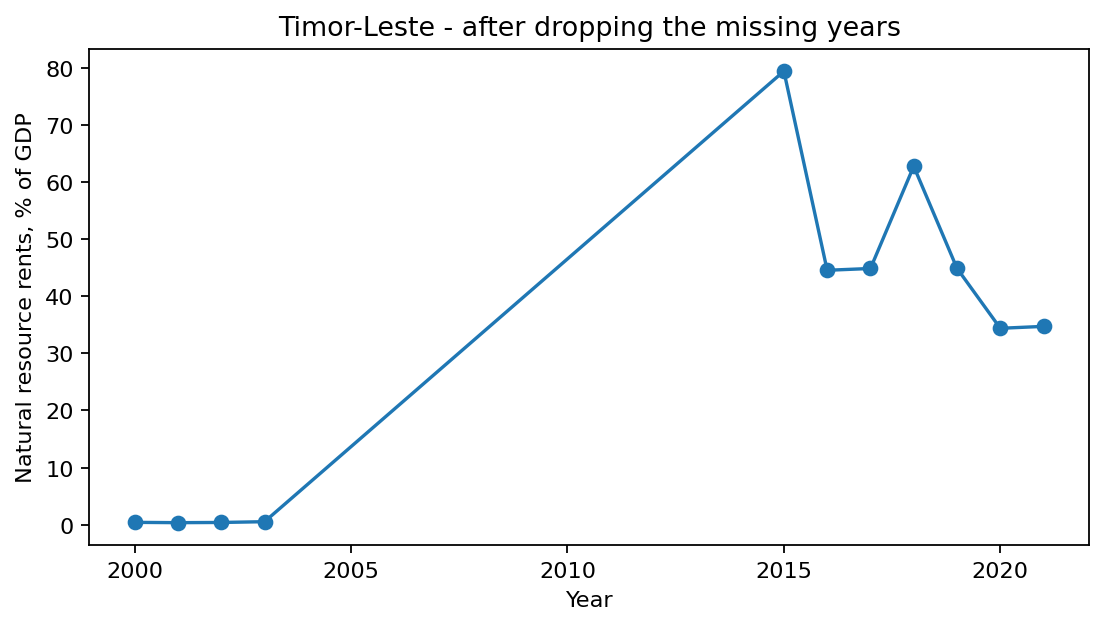

In [46]:
dropped = timor.dropna(subset=["nat_resources"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(dropped["year"], dropped["nat_resources"], marker="o")

ax.set_xlabel("Year")
ax.set_ylabel("Natural resource rents, % of GDP")
ax.set_title("Timor-Leste - after dropping the missing years")

plt.show()

That figure says Timor-Leste's resource rents climbed steadily from under 1% of GDP in 2003 to nearly

80% in 2015. A twelve-year ramp, smooth and convincing.



**No such climb was observed.** There is no figure for any year between 2004 and 2014. Everything

between those two points is a straight line matplotlib drew because we handed it two points and asked

for a line. Read the chart at 2009 and it tells you about 40% - a number that appears in no file

anywhere.



Now do it without dropping anything.

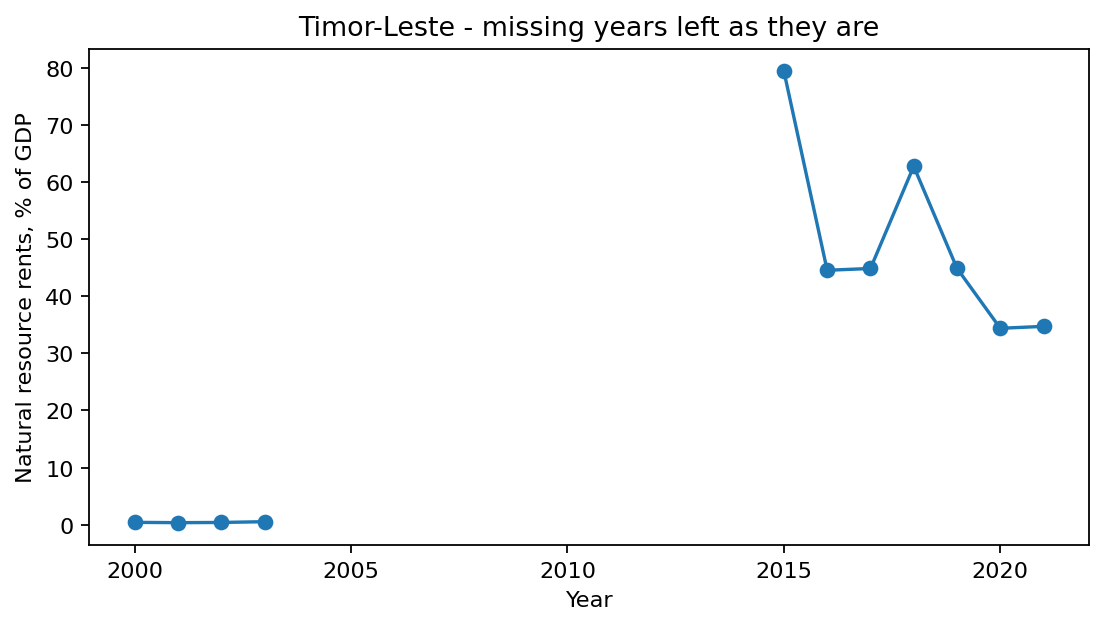

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(timor["year"], timor["nat_resources"], marker="o")

ax.set_xlabel("Year")
ax.set_ylabel("Natural resource rents, % of GDP")
ax.set_title("Timor-Leste - missing years left as they are")

plt.show()

The line breaks. `ax.plot` will not draw through a `NaN`, so the gap in the data becomes a gap in the figure, and a reader can see there is something they do not know.

The rule, and it is worth writing down:

> ⚠️ **Warning:** `dropna()` before a line chart turns *"we have no measurement"* into *"we measured a straight line"*. Drop rows only when you mean **these observations do not exist**. When you mean **these are missing**, leave them as `NaN` and let the gap show.



There is a second version of the same trap, and it is worse because there is nothing to see even in the data: rows that were **never in the file**. If a country simply has no 2008 row, the table looks complete and the line still bridges the gap. That is what `resample` was for last week - it builds a row for every period from the calendar, so a period with no observation arrives as `NaN` instead of quietly not being there.

> ⚠️ **Warning:** `ax.plot` connects points in the order you give them, not in order of x. A table that is not sorted produces a zigzag that looks like wild volatility. `sort_values("year")` before plotting a line, every time.

### 3.2 Comparing categories: `ax.bar`

`ax.bar` takes the category names and the heights.

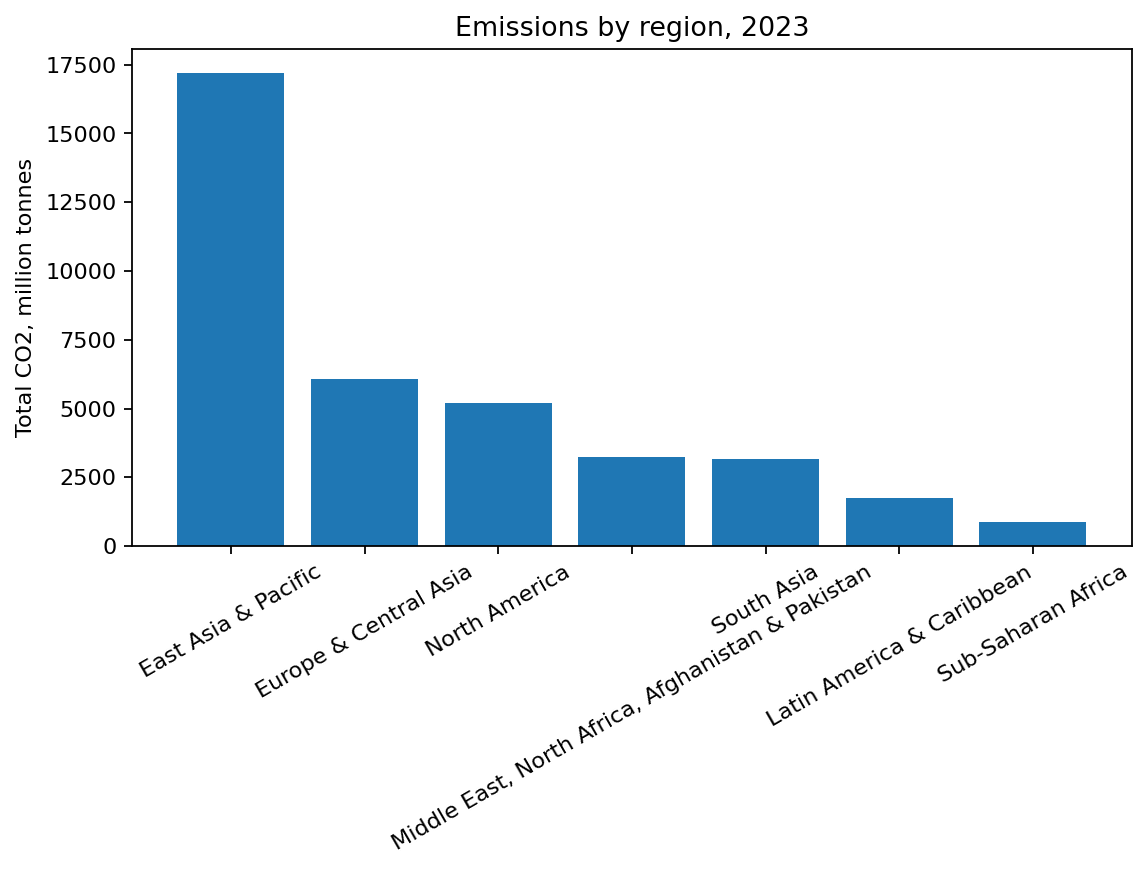

In [51]:
year_2023 = panel[panel["year"] == 2023]
totals = year_2023.groupby("region")["co2_total"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(totals.index, totals.values)

ax.set_ylabel("Total CO2, million tonnes")
ax.set_title("Emissions by region, 2023")
ax.tick_params(axis="x", rotation=30)

plt.show()

`ax.tick_params` controls how the tick marks and their labels are drawn - here `axis` says which axis and `rotation` says by how many degrees. This properly displays the labels without overlap.

An alternative is to turn the *chart*. `ax.barh` draws horizontal bars, so the category labels run along the y-axis where there is as much room as you want. Note that a horizontal bar chart is read from the bottom up, so sorting **ascending** puts the biggest bar at the top.

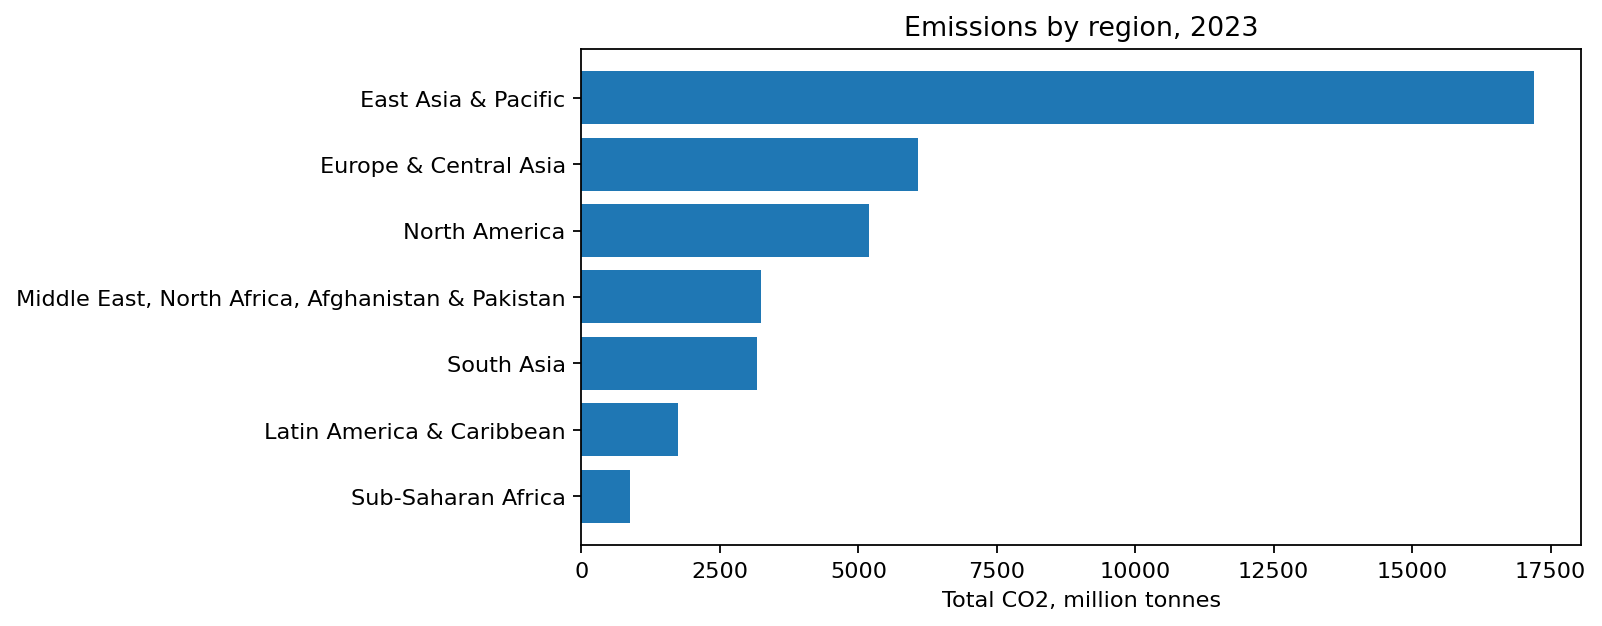

In [49]:
totals_up = year_2023.groupby("region")["co2_total"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(totals_up.index, totals_up.values)

ax.set_xlabel("Total CO2, million tonnes")
ax.set_title("Emissions by region, 2023")

plt.show()

> 💡 **Tip:** Sort before you draw a bar chart. Categories have no natural order, so unless there is a real one - months, income bands, years - the useful order is by size, and it costs one call to `sort_values`.

#### The second thing that fails quietly

The bar chat above displays total emissions, which is a fair thing to do. Now here is the same chart of an **average** instead - emissions per person, averaged across the countries of each region.

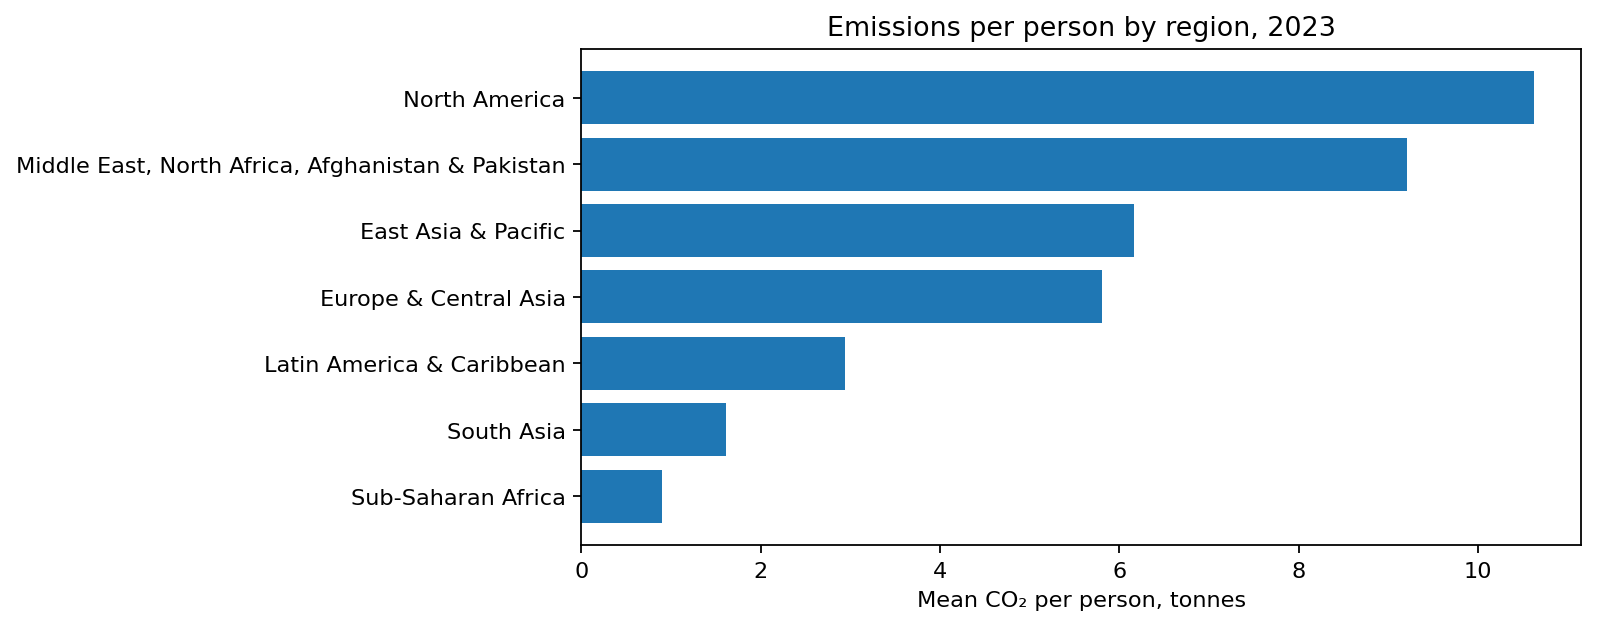

In [ ]:
mean_pc = year_2023.groupby("region")["co2_pc"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(mean_pc.index, mean_pc.values)

ax.set_xlabel("Mean CO2 per person, tonnes")
ax.set_title("Emissions per person by region, 2023")

plt.show()

North America is the worst by a distance, Sub-Saharan Africa the best. Both bars are arithmetically correct, but the figure has withheld the one thing you would want to know before believing it.

In [53]:
counts = year_2023.groupby("region").agg(
    mean_pc=("co2_pc", "mean"),
    countries=("co2_pc", "size"),
).sort_values("mean_pc")

counts.round(2)

,mean_pc,countries
region,,
Sub-Saharan Africa,0.90,47
South Asia,1.61,6
Latin America & Caribbean,2.94,39
Europe & Central Asia,5.81,49
East Asia & Pacific,6.17,37
"Middle East, North Africa, Afghanistan & Pakistan",9.21,22
North America,10.62,3


**North America's bar is an average of three countries. Sub-Saharan Africa's is an average of 47.**

Nothing in the chart says so, and the two bars are drawn identically. The honest version puts the count where the reader will see it. Building the labels yourself is one list comprehension:

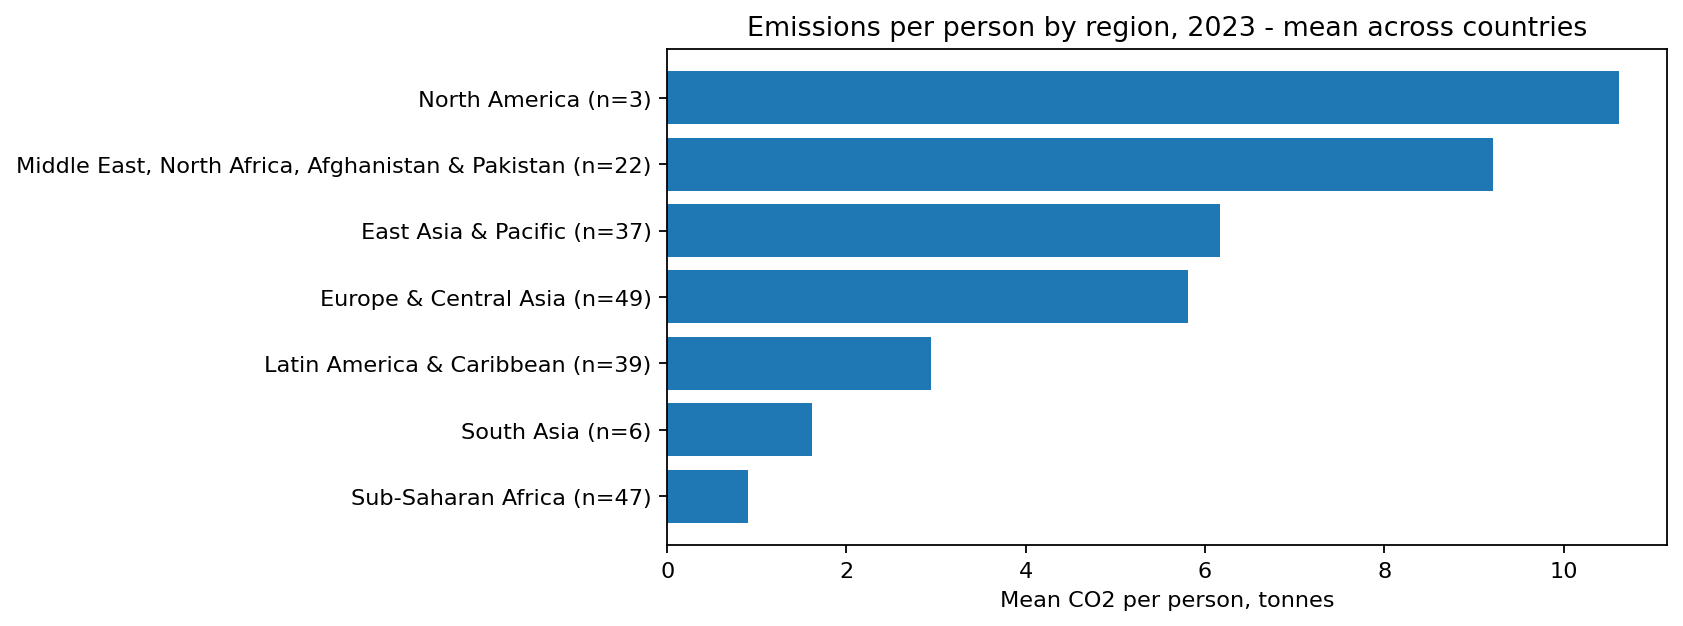

In [54]:
labels = [f"{name} (n={n})" for name, n in zip(counts.index, counts["countries"])]

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(labels, counts["mean_pc"])

ax.set_xlabel("Mean CO2 per person, tonnes")
ax.set_title("Emissions per person by region, 2023 - mean across countries")

plt.show()

Same bars, and now nobody can misread them by accident. The title says *mean across countries*, which is the other half of the fix: a chart of a summary statistic should say which statistic. For example, a mean across countries and a mean across *people* are different questions, and last week's `.apply()` on a groupby was how you get the second one.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Draw a readable bar chart. In a single cell, load the file below, take the ten countries with the highest total emissions in 2023, and draw them as a horizontal bar chart sorted by size, with an axis label giving the units and a title.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

df = co2.merge(info[["code", "region"]], on="code", how="left")

df = df[(df["region"] != "Aggregates") & (df["year"] == 2023)]</code></pre>

</div>

NameError: name 'df' is not defined

### 3.3 Two variables together: `ax.scatter`



A scatter plot asks whether two measurements move together. It takes an x and a y and draws one point per row - so unlike everything above, it does **not** want a summary. It wants the rows.

Richer countries emit more. Do they?

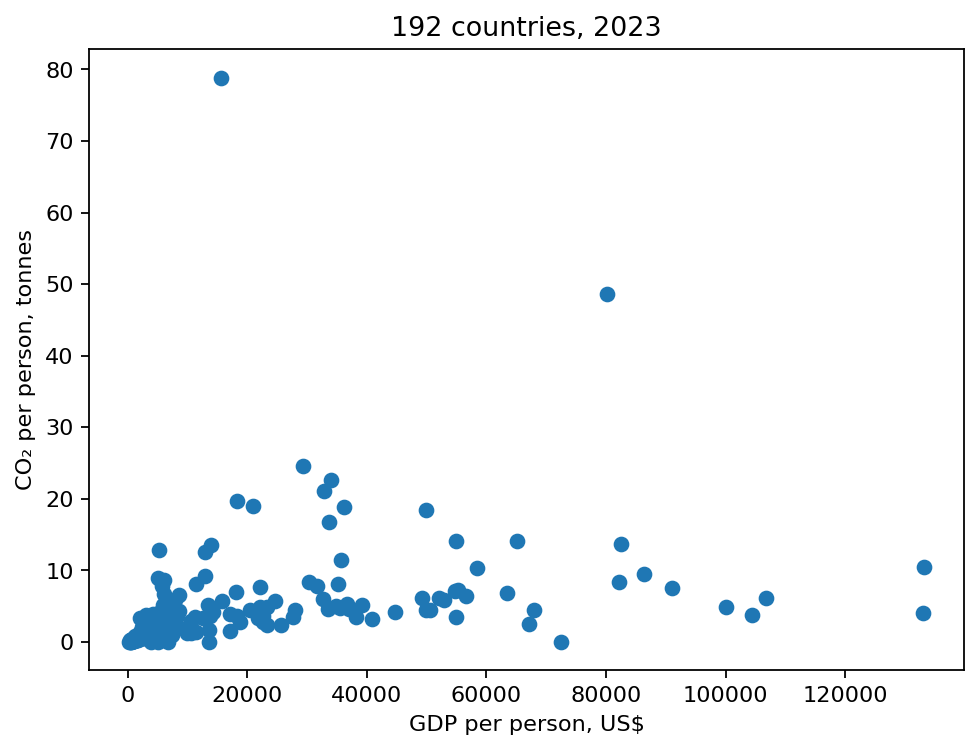

In [ ]:
points = year_2023.dropna(subset=["gdp_pc", "co2_pc"])

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(points["gdp_pc"], points["co2_pc"])

ax.set_xlabel("GDP per person, US$")
ax.set_ylabel("CO2 per person, tonnes")
ax.set_title(f"{len(points)} countries, 2023")

plt.show()

Something is there, and most of the data is jammed into the left-hand fifth of the figure. That is because GDP per person runs from about 250 dollars to about 133 000 - a factor of over 500 - and a linear axis gives the poorest hundred countries almost no room.

`ax.set_xscale("log")` puts the x-axis on a **logarithmic** scale, where equal distances are equal *ratios* rather than equal differences: the gap from 1 000 to 10 000 is the same width as the gap from 10 000 to 100 000.

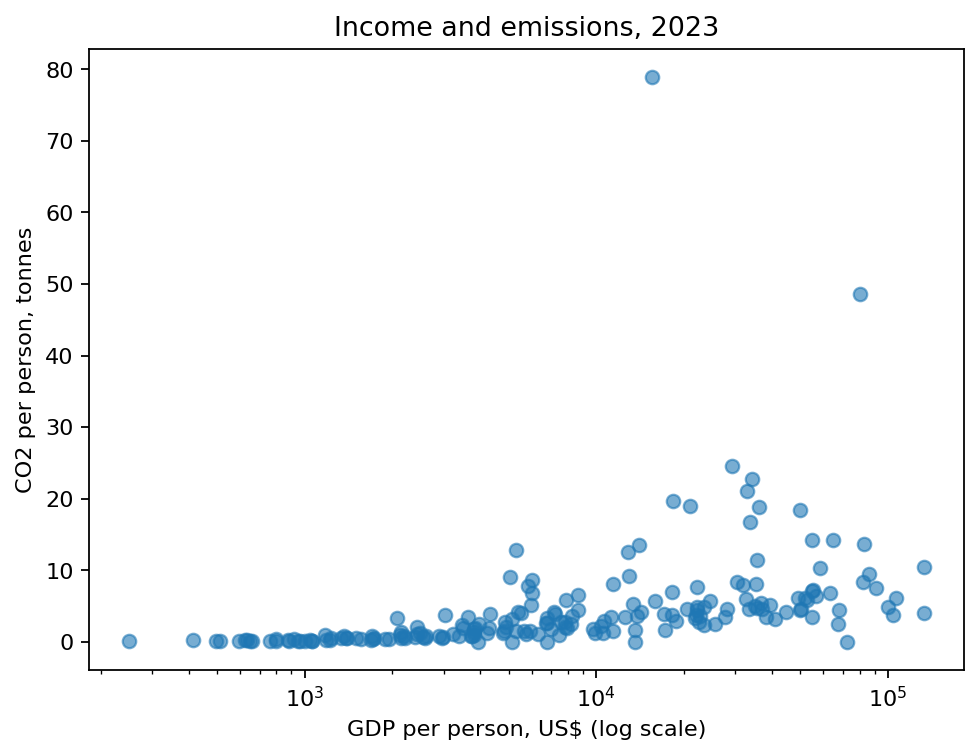

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(points["gdp_pc"], points["co2_pc"], alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel("GDP per person, US$ (log scale)")
ax.set_ylabel("CO2 per person, tonnes")
ax.set_title("Income and emissions, 2023")

plt.show()

Now the countries are spread across the figure and the relationship is visible. `alpha=0.6` makes each point slightly transparent, so that a place where several points overlap comes out darker instead of looking like one point.

The eye is not being fooled here - the numbers agree. `.corr()` gives the correlation between two columns, a number between -1 and 1 saying how tightly they move together:

In [58]:
print("raw GDP per person: ", round(points["gdp_pc"].corr(points["co2_pc"]), 3))
print("log GDP per person: ", round(np.log(points["gdp_pc"]).corr(points["co2_pc"]), 3))

raw GDP per person:  0.322
log GDP per person:  0.419


0.32 against 0.42. The relationship was always there; on the raw scale it was being flattened by a handful of very rich countries a long way to the right.

> ⚠️ **Warning:** A log scale cannot show zero or a negative number, and it does not tell you when it drops one. Two countries in this table have emissions per person of exactly 0.0 - had we put the *y*-axis on a log scale as well, both would have vanished from the figure with no error and no
warning.

#### Color by group

The same loop-over-groups from earlier works here, one `ax.scatter` per region:

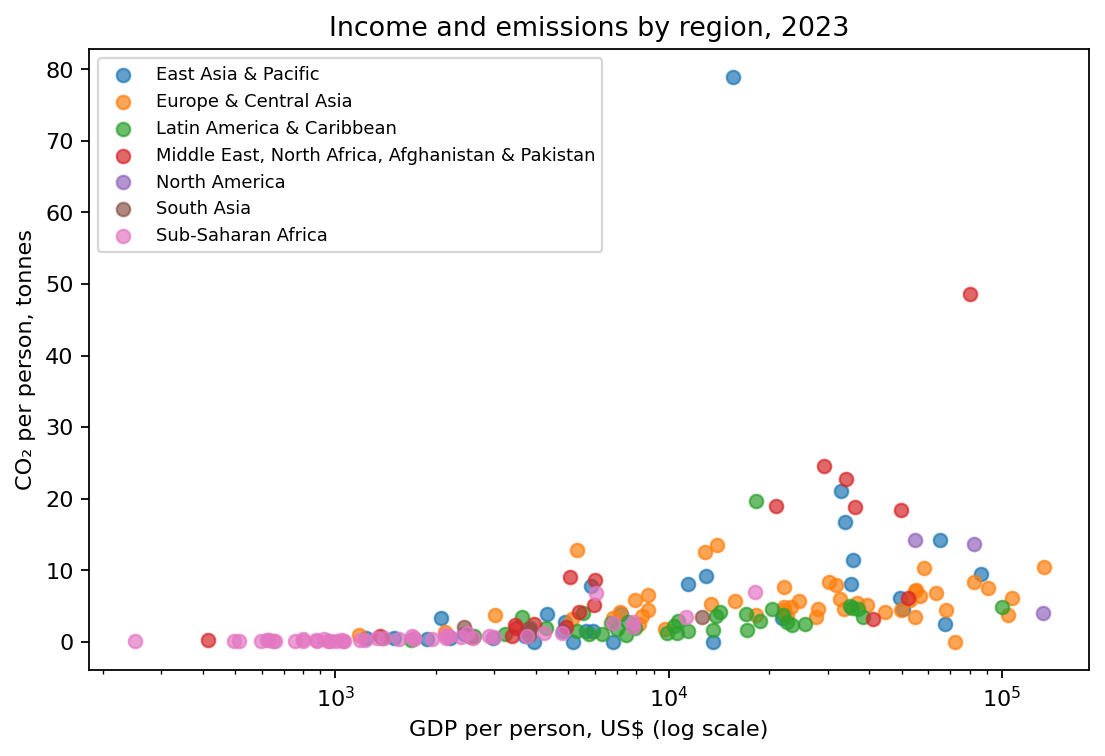

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, group in points.groupby("region"):
    ax.scatter(group["gdp_pc"], group["co2_pc"], label=name, alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel("GDP per person, US$ (log scale)")
ax.set_ylabel("CO₂ per person, tonnes")
ax.legend(fontsize=8)
ax.set_title("Income and emissions by region, 2023")

plt.show()

matplotlib gives each call the next color in its default cycle, so you get seven colors without asking for any. The cycle has ten entries and then repeats - if you ever loop over more than ten groups, two of them will be drawn identically and the legend will not save you.

### 3.4 One variable, spread out: `ax.hist`

The bar chart in 3.2 replaced 203 countries with seven averages. A histogram does the opposite: it keeps every observation, cuts the range into intervals, and counts how many fall in each.

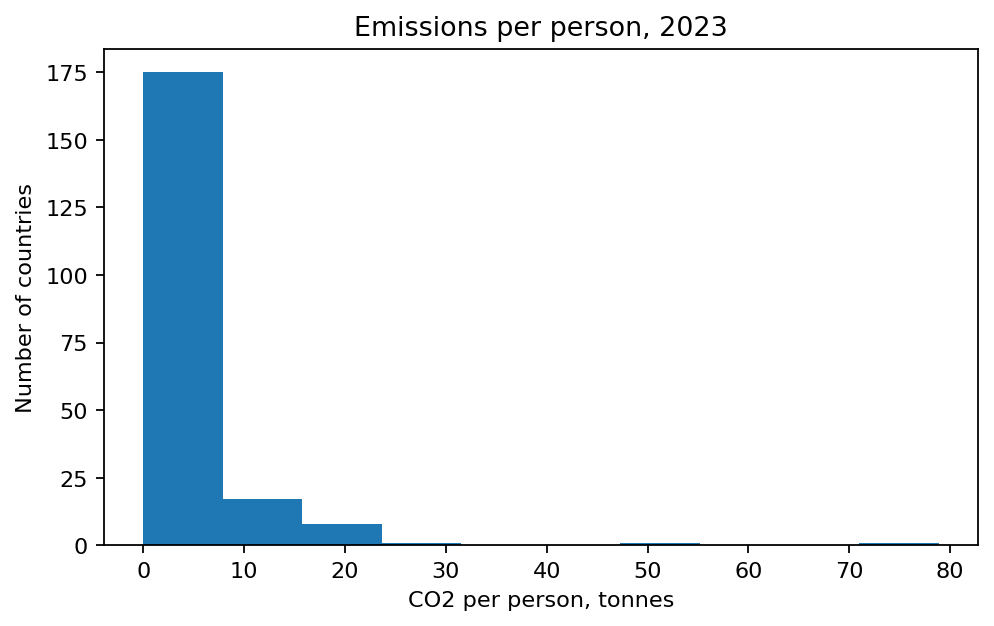

In [62]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(year_2023["co2_pc"].dropna())

ax.set_xlabel("CO2 per person, tonnes")
ax.set_ylabel("Number of countries")
ax.set_title("Emissions per person, 2023")

plt.show()

Almost everything is in the first bar and there is a long thin tail to the right.

`bins=` controls how many intervals the range is cut into. It is the one argument that changes what the chart says, so it is worth trying more than one value.

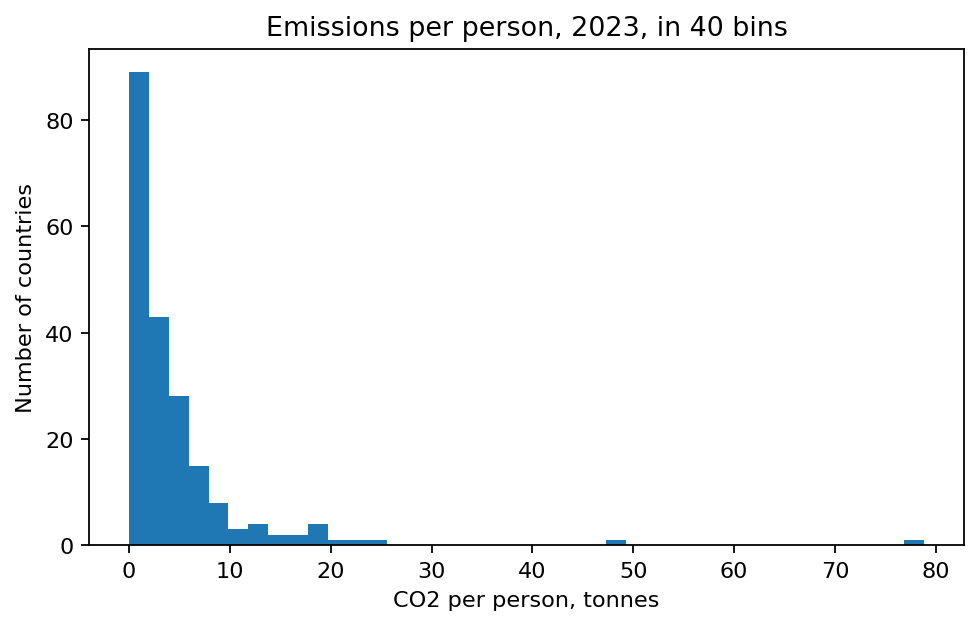

In [63]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(year_2023["co2_pc"].dropna(), bins=40)

ax.set_xlabel("CO2 per person, tonnes")
ax.set_ylabel("Number of countries")
ax.set_title("Emissions per person, 2023, in 40 bins")

plt.show()

Same data, and now you can see the shape of the bulk of it instead of one enormous bar.

`ax.axvline` draws a vertical line right across the axes at an x value you give it - useful for marking a reference point such as an average.

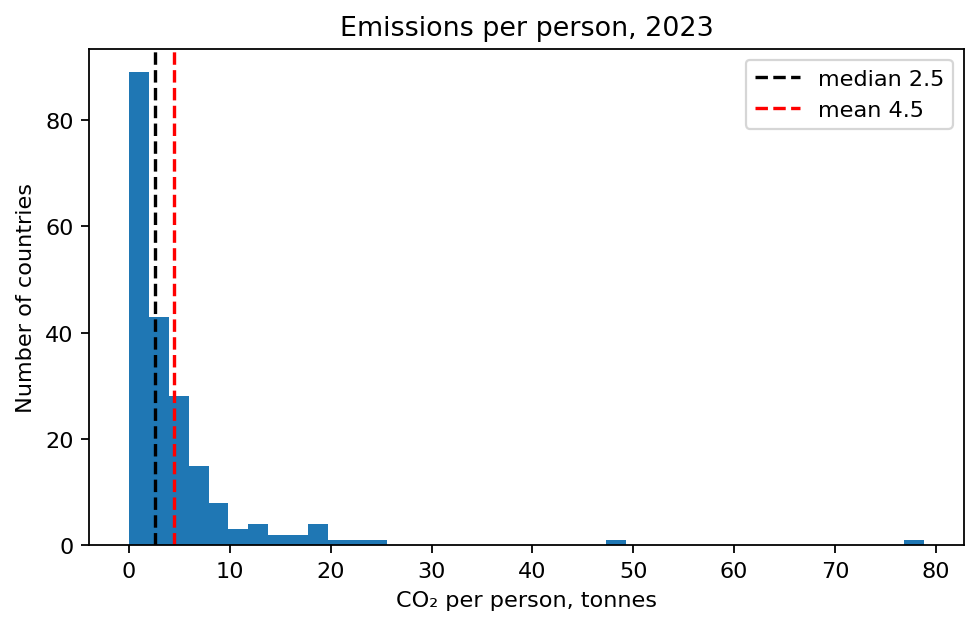

In [64]:
values = year_2023["co2_pc"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(values, bins=40)

ax.axvline(values.median(), color="black", linestyle="--", label=f"median {values.median():.1f}")
ax.axvline(values.mean(), color="red", linestyle="--", label=f"mean {values.mean():.1f}")

ax.set_xlabel("CO₂ per person, tonnes")
ax.set_ylabel("Number of countries")
ax.legend()
ax.set_title("Emissions per person, 2023")

plt.show()

The median is 2.5 tonnes and the mean is 4.5 - the mean is nearly **eighty percent higher**, because a few countries at the far right pull it up while three quarters of the world sits below 5.

That is the argument for this chart type. The bar chart of regional means back in 3.2 is built out of exactly these numbers, and could not have told you that the distribution behind them looks like this. 

## 4. Making a chart readable

The four sections above were about choosing the chart. This one is about finishing it.

A figure that leaves your screen has to survive without you standing next to it. The checklist is short, and none of it is optional:

| Every figure needs | How |
|---|---|
| an x-axis label, **with units** | `ax.set_xlabel` |
| a y-axis label, **with units** | `ax.set_ylabel` |
| a title saying what you are looking at | `ax.set_title` |
| a legend, if there is more than one series | `label=` on each, then `ax.legend()` |
| limits that do not mislead | `ax.set_xlim`, `ax.set_ylim` |
| ticks a human can read | `ax.tick_params`, `ax.grid` |

We will take one chart and finish it properly. Last week's NASDAQ file: the daily closing level of a US stock index, from February 1971 to December 2025.

In [67]:
nasdaq = pd.read_csv("../data/NASDAQ.csv")
nasdaq["Date"] = pd.to_datetime(nasdaq["Date"], format="%Y-%m-%d")

prices = nasdaq.set_index("Date").sort_index()["NASDAQ"]
monthly = prices.resample("ME").last()

print(len(prices), "trading days ->", len(monthly), "months")
monthly.head(3)

13842 trading days -> 659 months


Date
1971-02-28    101.3
1971-03-31    106.0
1971-04-30    112.3
Freq: ME, Name: NASDAQ, dtype: float64

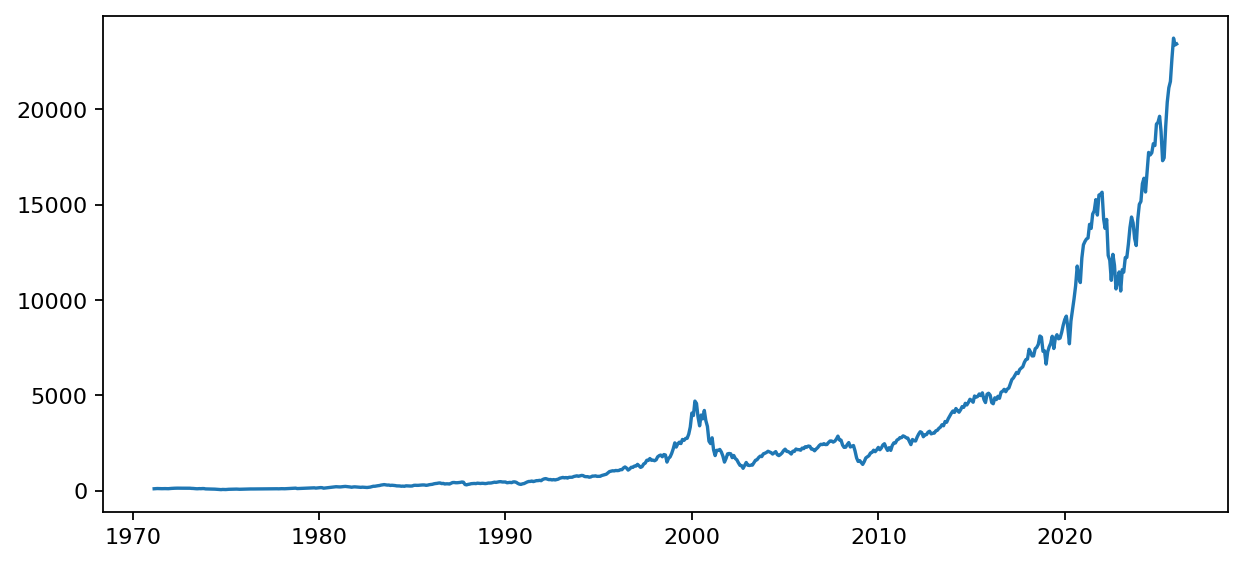

In [66]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(monthly.index, monthly.values)

plt.show()

Two things already work without being asked. The x-axis shows years rather than numbers, because the index is a real datetime after last week's `to_datetime` - that is the whole payoff of converting it. And the line is in date order because we sorted it.

Everything else is wrong.

### Scale

The index started at 100 and ended above 23 000. On a linear axis the first thirty years of the series are a flat line along the bottom, and the crash of 2000 - which took the index down by 78% and was the defining market event of a generation - is a small wiggle.

`ax.set_yscale("log")` is the fix, for the same reason as in 3.3: on a log axis a fall of half is the same distance wherever it happens, so a percentage change looks the same size in 1975 as in 2020.

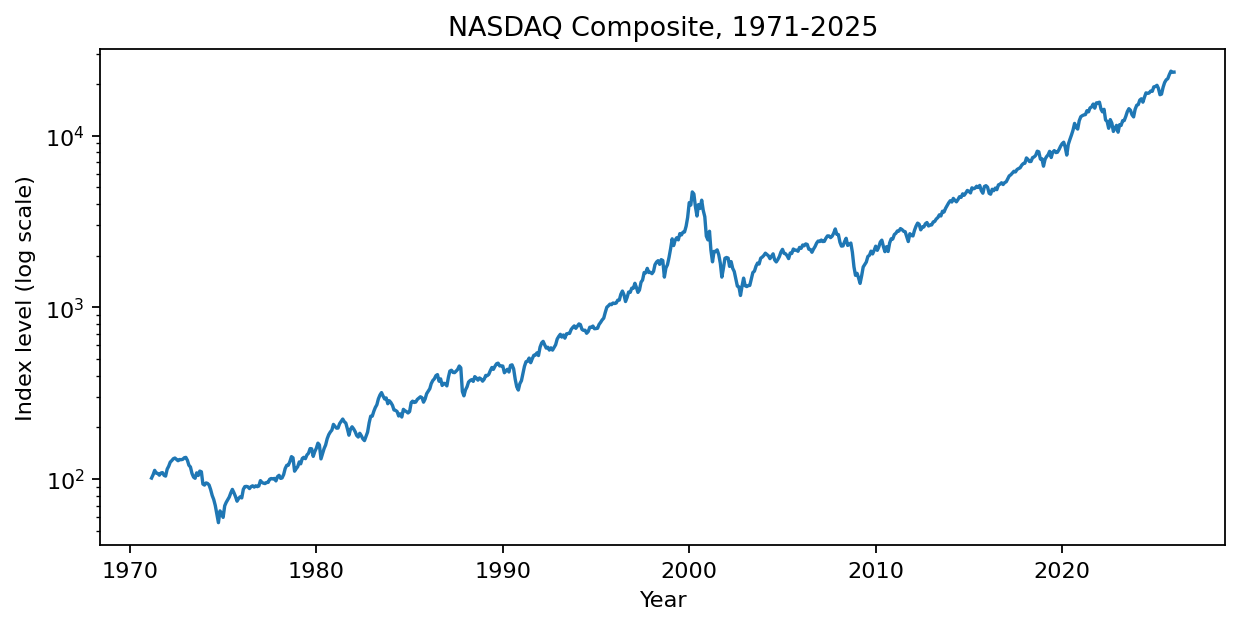

In [68]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(monthly.index, monthly.values)

ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Index level (log scale)")
ax.set_title("NASDAQ Composite, 1971-2025")

plt.show()

The 1970s are now visible, and so is the fact that the fall after 2000 was far larger than anything before it.

### Grid, limits, and a shaded period

`ax.grid` draws grid lines. `ax.set_xlim` and `ax.set_ylim` set the range of an axis. And `ax.axvspan` shades a vertical band between two x values, which is how you mark a period on a time series - `alpha` again to keep it behind the data rather than on top of it.

In [69]:
peak_date = prices.loc["2000"].idxmax()
low_date = prices.loc["2002"].idxmin()

print("peak:", peak_date.date(), round(prices.loc[peak_date], 1))
print("low: ", low_date.date(), round(prices.loc[low_date], 1))
print("fall:", round((prices.loc[low_date] / prices.loc[peak_date] - 1) * 100, 1), "%")

peak: 2000-03-10 5048.6
low:  2002-10-09 1114.1
fall: -77.9 %


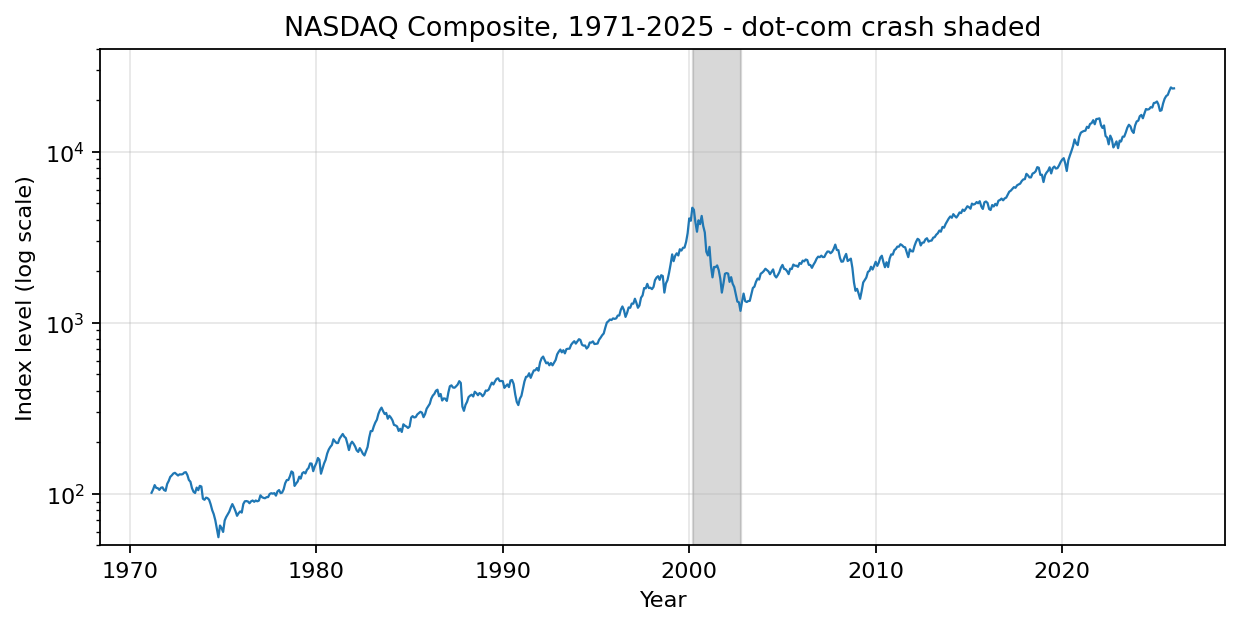

In [70]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(monthly.index, monthly.values, linewidth=1)

ax.axvspan(peak_date, low_date, color="gray", alpha=0.3)

ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylim(50, 40000)
ax.set_xlabel("Year")
ax.set_ylabel("Index level (log scale)")
ax.set_title("NASDAQ Composite, 1971-2025 - dot-com crash shaded")

plt.show()

### Saying something on the figure

`ax.text` puts a string at coordinates you give **in the units of the data** - so on this figure the x coordinate has to be a date, and `pd.Timestamp` is how you write one on its own. It is how you point at the thing you want the reader to look at, instead of hoping they find it.

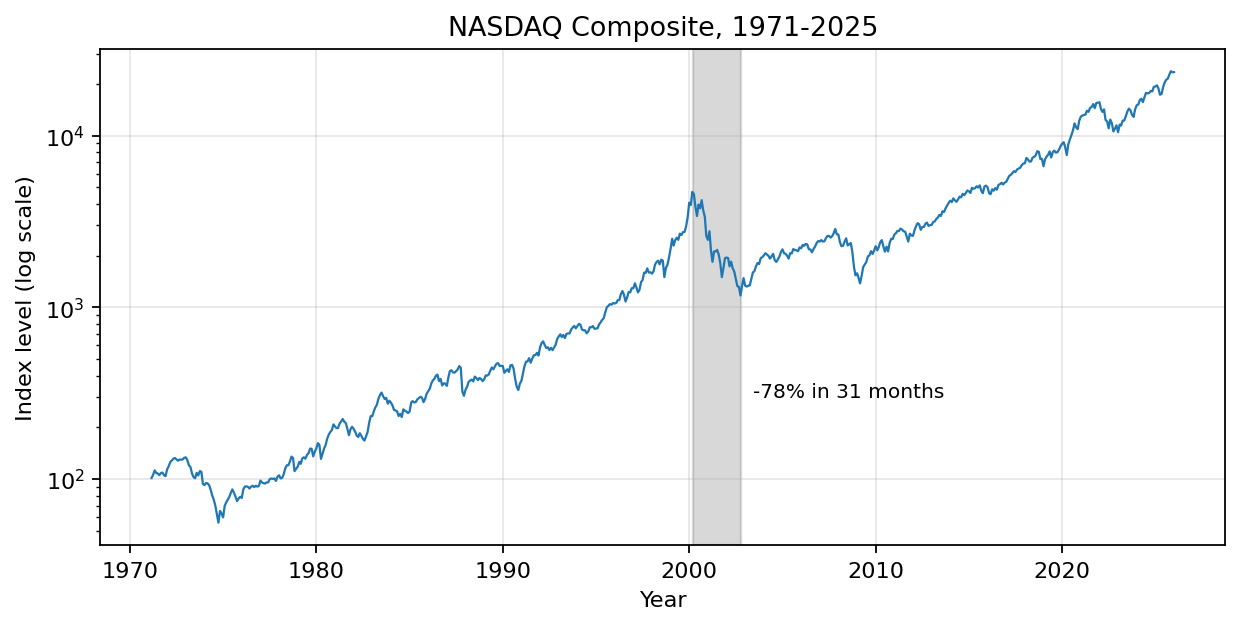

In [71]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(monthly.index, monthly.values, linewidth=1)

ax.axvspan(peak_date, low_date, color="gray", alpha=0.3)

ax.text(pd.Timestamp("2003-06-01"), 300, "-78% in 31 months", fontsize=9)

ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_xlabel("Year")
ax.set_ylabel("Index level (log scale)")
ax.set_title("NASDAQ Composite, 1971-2025")

plt.show()

That figure now makes a claim, and a reader can check it against the line.

For the record, the index did not close above its March 2000 peak again until **April 2015** - fifteen years. Whether that belongs on the chart depends entirely on what you are arguing.

### Styles

`plt.style.use` changes the defaults for everything drawn afterwards - background, grid, colors, fonts - in one line. `plt.style.available` lists what your installation has.

In [73]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


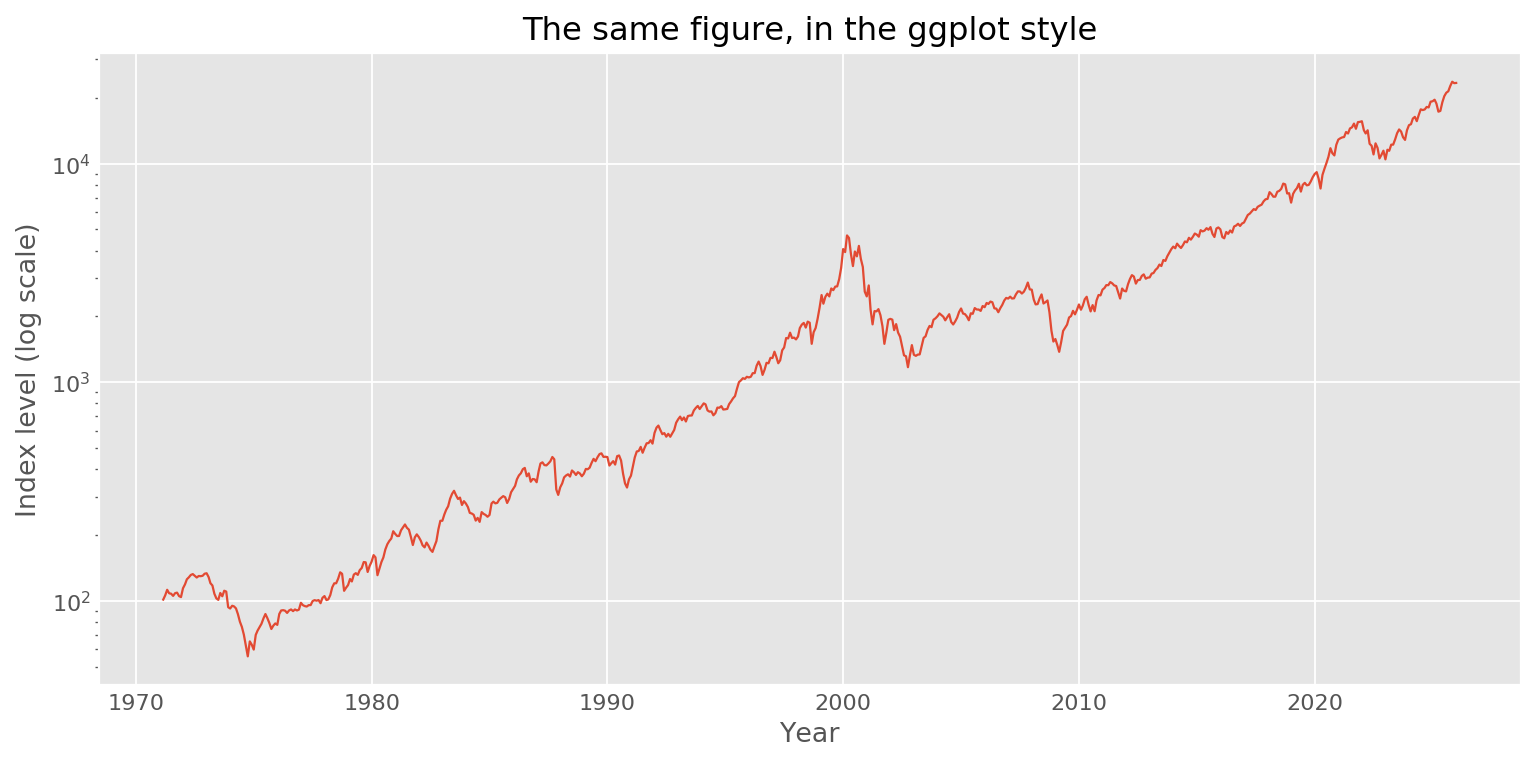

In [77]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(monthly.index, monthly.values, linewidth=1)

ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Index level (log scale)")
ax.set_title("The same figure, in the ggplot style")

plt.show()

> ⚠️ **Warning:** `plt.style.use` is **global and sticky**. Every figure you draw for the rest of the session uses it, including the ones above if you re-run them. `plt.style.use("default")` puts it back.

Style sheets are worth exactly one line at the top of a notebook and no more thought than that. A consistent look across a report matters; which look it is does not.

In [80]:
plt.style.use("default")

However, note that you can apply a style sheet to a single plot by placing the plotting code inside a `with` statement:

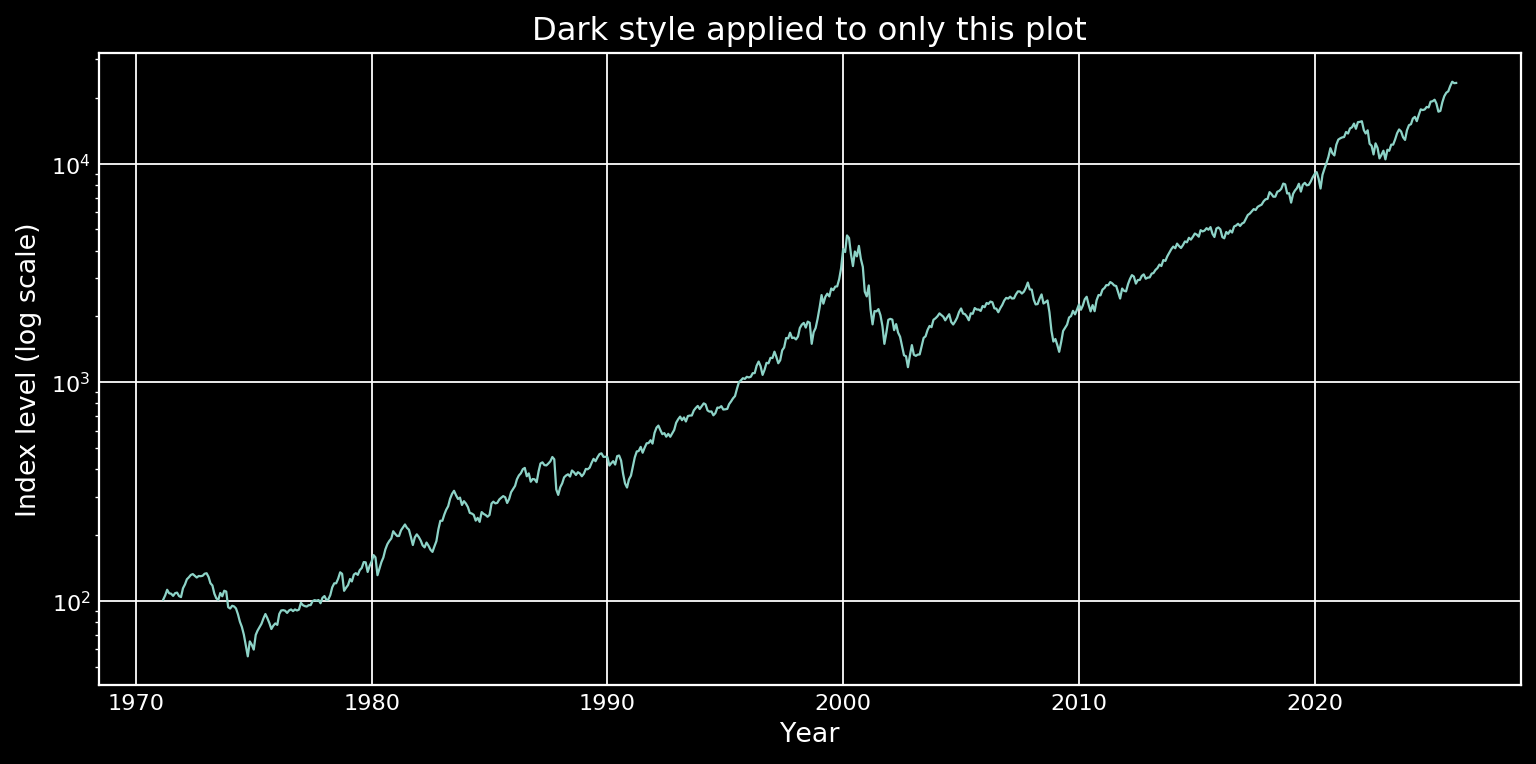

In [79]:
with plt.style.context("dark_background"):

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(monthly.index, monthly.values, linewidth=1)

    ax.set_yscale("log")
    ax.set_xlabel("Year")
    ax.set_ylabel("Index level (log scale)")
    ax.set_title("Dark style applied to only this plot")

    plt.show()


<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Finish a figure. In a single cell, load the file below, draw the monthly closing level of the NASDAQ from 2015 onwards as a line, and make it presentable: axis labels with units, a title, a grid, and a horizontal reference line at the level the index reached on the last day of 2019, using
<code>ax.axhline</code>, which works like <code>ax.axvline</code> but across the other axis.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>nasdaq = pd.read_csv("../data/NASDAQ.csv")
nasdaq["Date"] = pd.to_datetime(nasdaq["Date"], format="%Y-%m-%d")
prices = nasdaq.set_index("Date").sort_index()["NASDAQ"]</code></pre>

</div>

## 5. Several panels in one figure

`plt.subplots` has been making one set of axes because we never asked it for more. `nrows` and `ncols` ask for a grid, and then instead of a single `ax` you get an **array** of them.

<class 'numpy.ndarray'>
shape: (2,)


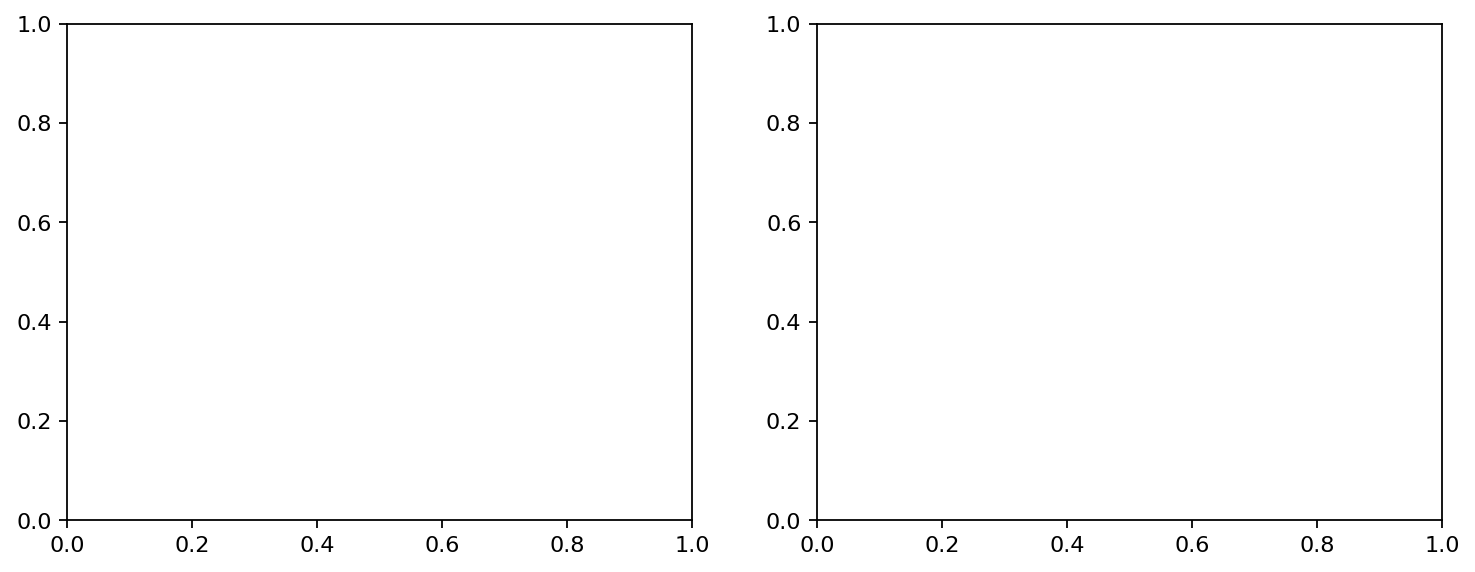

In [81]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

print(type(axes))
print("shape:", axes.shape)

A NumPy array of two `Axes` objects, so `axes[0]` is the left panel and `axes[1]` the right one. Each of them takes exactly the same methods as before, and the figure as a whole gets its own overall title from `fig.suptitle`.

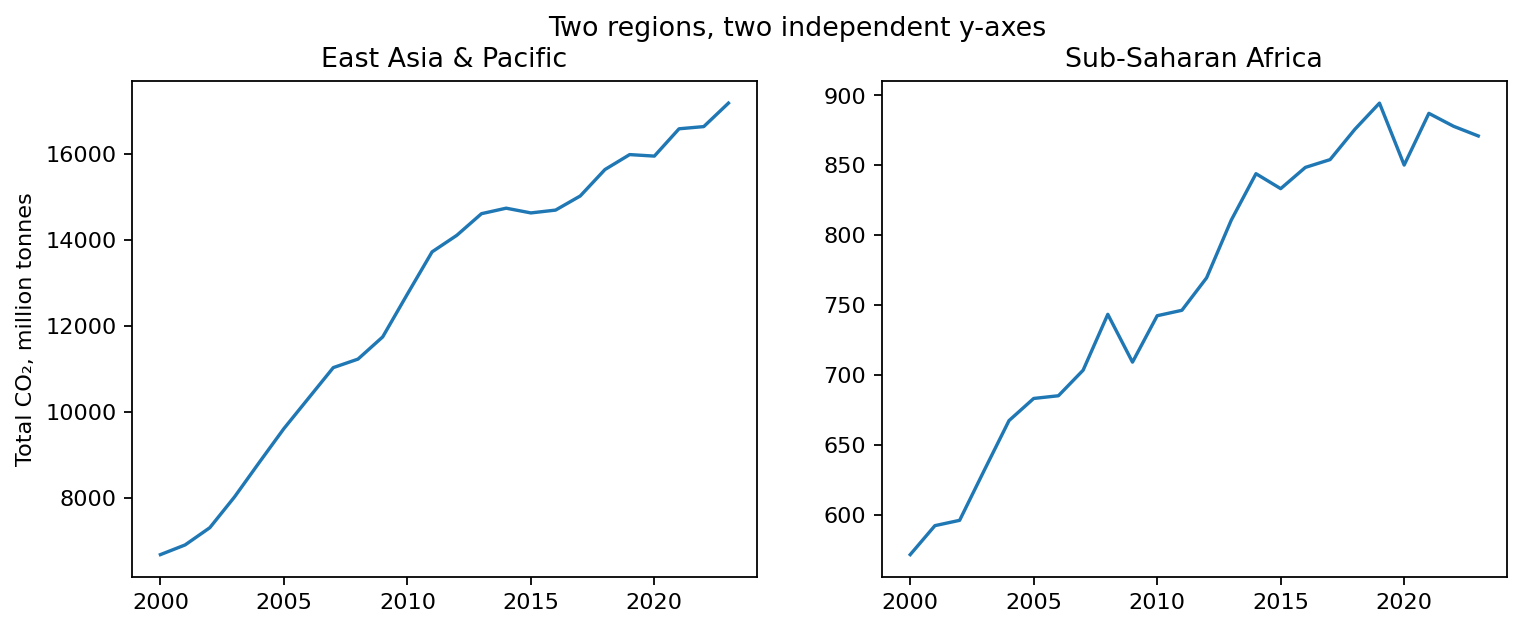

In [ ]:
east = panel[panel["region"] == "East Asia & Pacific"].groupby("year")["co2_total"].sum()
africa = panel[panel["region"] == "Sub-Saharan Africa"].groupby("year")["co2_total"].sum()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

axes[0].plot(east.index, east.values)
axes[0].set_title("East Asia & Pacific")
axes[0].set_ylabel("Total CO2, million tonnes")

axes[1].plot(africa.index, africa.values)
axes[1].set_title("Sub-Saharan Africa")

fig.suptitle("Two regions, two independent y-axes")

plt.show()

`fig.suptitle` is the one title that belongs to the whole figure rather than to a panel - the sort of thing `fig` owns and `ax` does not.

And the figure is **misleading**, badly. Both lines rise at roughly the same angle to roughly the same height, so the two regions look comparable. They are not: East Asia ends 2023 at 17 193 million tonnes and Sub-Saharan Africa at 871, a factor of twenty. Each panel silently chose its own y-axis to fit its own data.

`sharey=True` makes every panel use one y-axis.

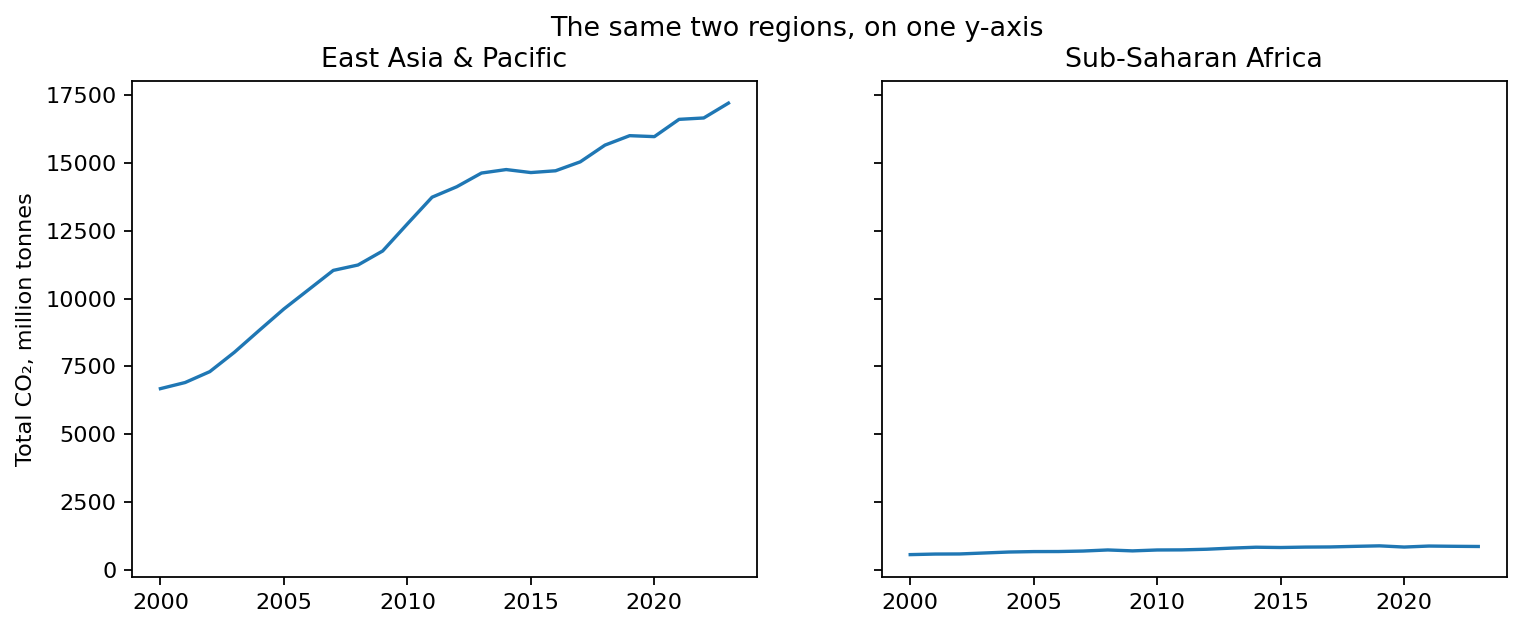

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4), sharey=True)

axes[0].plot(east.index, east.values)
axes[0].set_title("East Asia & Pacific")
axes[0].set_ylabel("Total CO2, million tonnes")

axes[1].plot(africa.index, africa.values)
axes[1].set_title("Sub-Saharan Africa")

fig.suptitle("The same two regions, on one y-axis")

plt.show()

Sub-Saharan Africa is now a nearly flat line along the bottom, which is what the data says. There is also `sharex=True`, which does the same for the x-axis and is worth having whenever the panels cover the same period.

> ⚠️ **Warning:** Panels side by side are an invitation to compare them. If their axes differ, the comparison the reader makes is not the one the numbers support. Either share the axis or say loudly on the figure that you did not.

### A panel per group, with a loop

Seven regions want a grid, and a grid of `nrows=2, ncols=4` has eight cells. `axes.flatten()` turns the two-dimensional array into a flat one you can walk through with `zip`, exactly as you would any other pair of sequences. Two `fig` methods finish it off: `fig.delaxes` throws away the eighth panel, which has nothing in it, and `fig.tight_layout` shuffles everything so the titles and labels stop colliding.

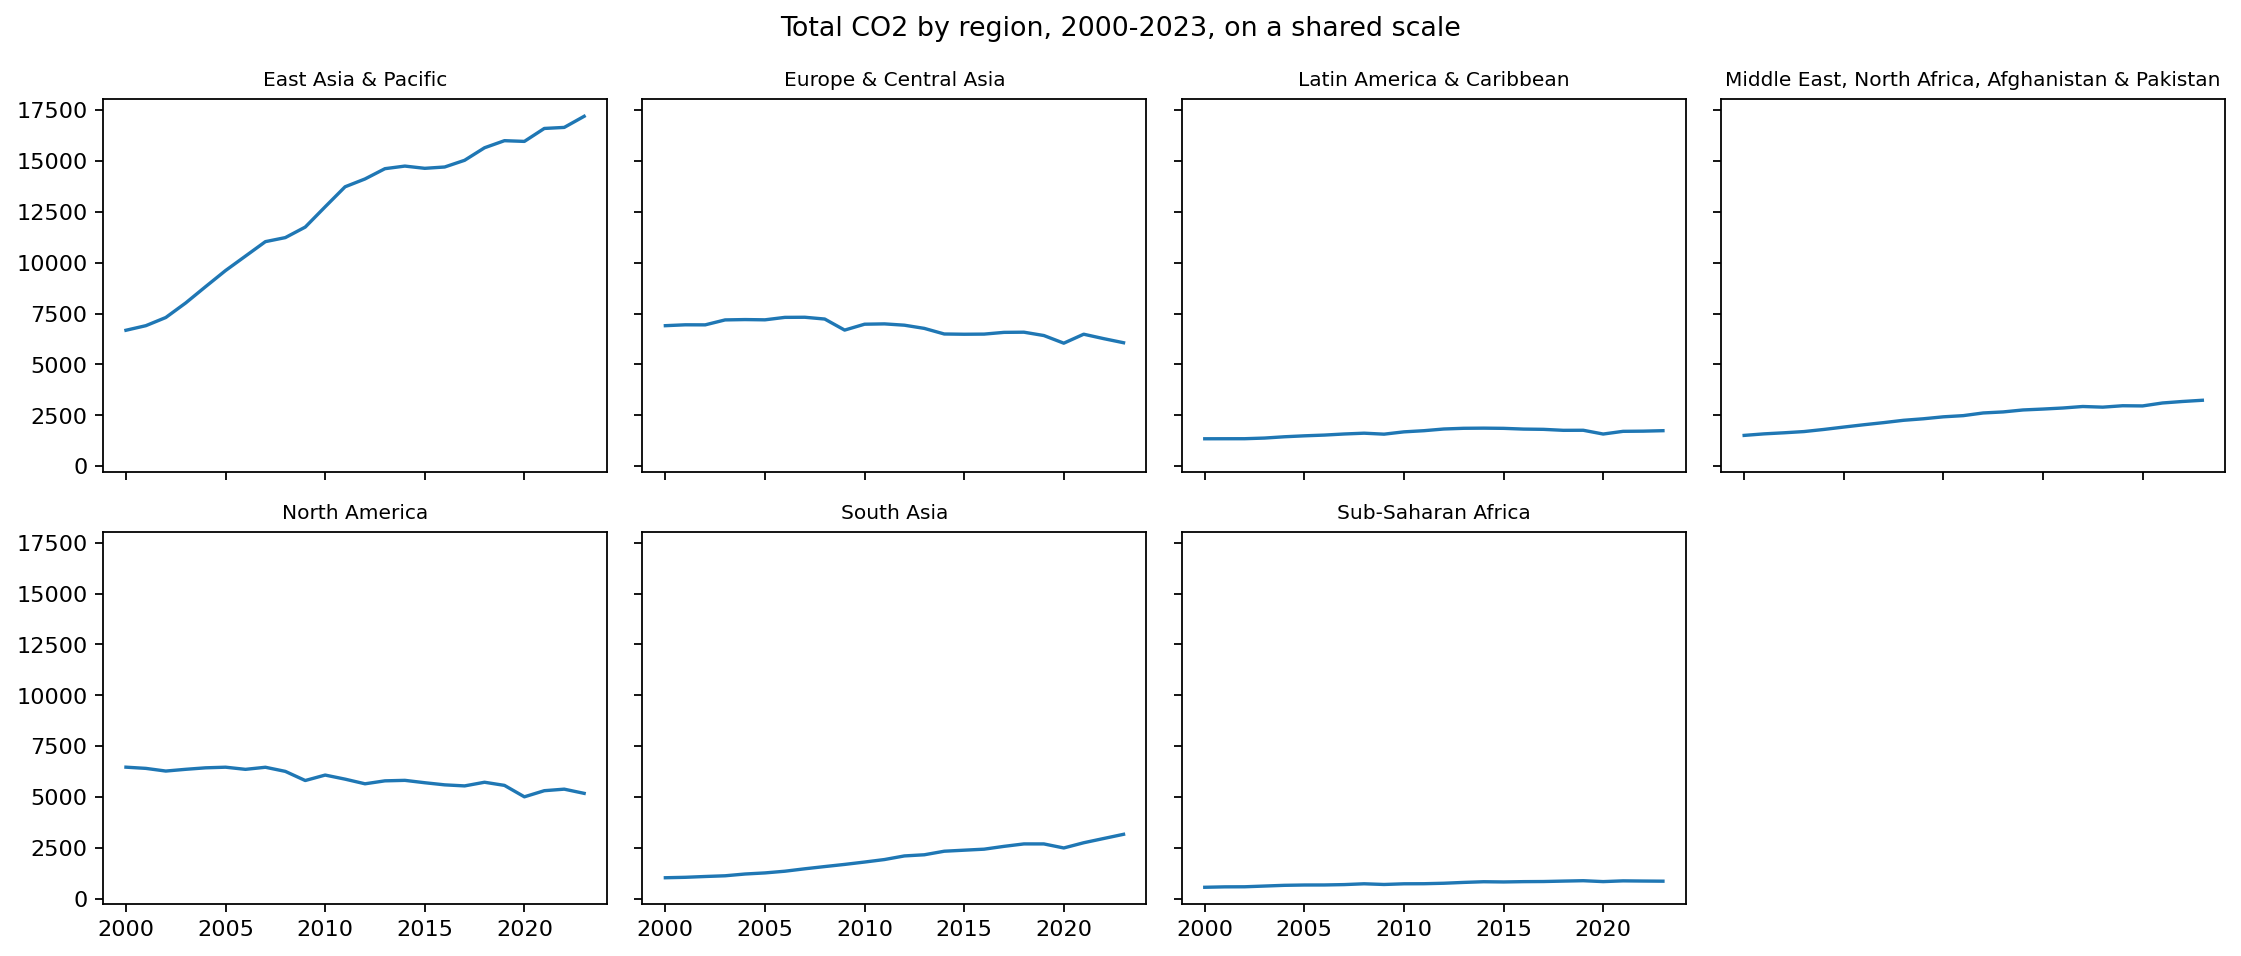

In [89]:
regions = sorted(panel["region"].unique())

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 6), sharex=True, sharey=True)

faxes = axes.flatten()

for i, ax in enumerate(faxes):
    if i < len(regions):
        region = regions[i]
        rows = panel[panel["region"] == region].groupby("year")["co2_total"].sum()
        ax.plot(rows.index, rows.values)
        ax.set_title(region, fontsize=9)
    else:
        ax.set_visible(False)

fig.suptitle("Total CO2 by region, 2000-2023, on a shared scale")

fig.tight_layout()
plt.show()

Three things in that cell are worth naming:
- **`if` stops at the shorter sequence**, so seven regions against eight axes fills seven panels and leaves the eighth alone. That is not a mistake to be tidied up - it is why the loop is safe.
- **`ax.set_visible`** simply hides the axes object from view (does not delete it)
- **`fig.tight_layout()`** goes last, once everything else is on the figure.

Seven panels for the price of four lines of drawing code, and adding an eighth region changes nothing except the number of rows in the grid.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Build a two-panel figure. In a single cell, load the file below and draw two panels side by side for 2023: on the left a histogram of <code>co2_pc</code>, on the right a scatter of <code>gdp_pc</code> against <code>co2_pc</code>. Give each panel its own axis labels and title, and
the figure a <code>suptitle</code>.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

df = co2.merge(info[["code", "region"]], on="code", how="left")
df = df[(df["region"] != "Aggregates") & (df["year"] == 2023)]
df["co2_pc"] = df["co2_total"] * 1_000_000 / df["population"]</code></pre>

</div>

## 6. A function that draws a figure

Look back at the last loop. Every panel needed the same handful of lines with one thing changed. Look back at section 3: the bar chart of 2023 would need the same treatment for 2010, and for 2000, and for every year somebody asks about.

That is the situation functions exist for, and nothing about the fact that the output is a picture rather than a number changes the rules from Part 1.

In [90]:
def plot_region(data, region):
    """
    Draw total CO2 emissions over time for one region.

    Parameters
    ----------
    data : DataFrame
        Panel with columns "region", "year" and "co2_total".
    region : str
        Name of the region to draw. Must appear in data["region"].
    
    Returns
    -------
    Figure
        The finished figure.

    Raises
    ------
    ValueError
        If region is not one of the regions in data.
    """

    if region not in data["region"].unique():
        raise ValueError(f"no region called '{region}' in this table")

    rows = data[data["region"] == region].groupby("year")["co2_total"].sum()

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(rows.index, rows.values)

    ax.set_xlabel("Year")
    ax.set_ylabel("Total CO2, million tonnes")
    ax.set_title(f"{region}: total CO2 emissions")
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

    return fig

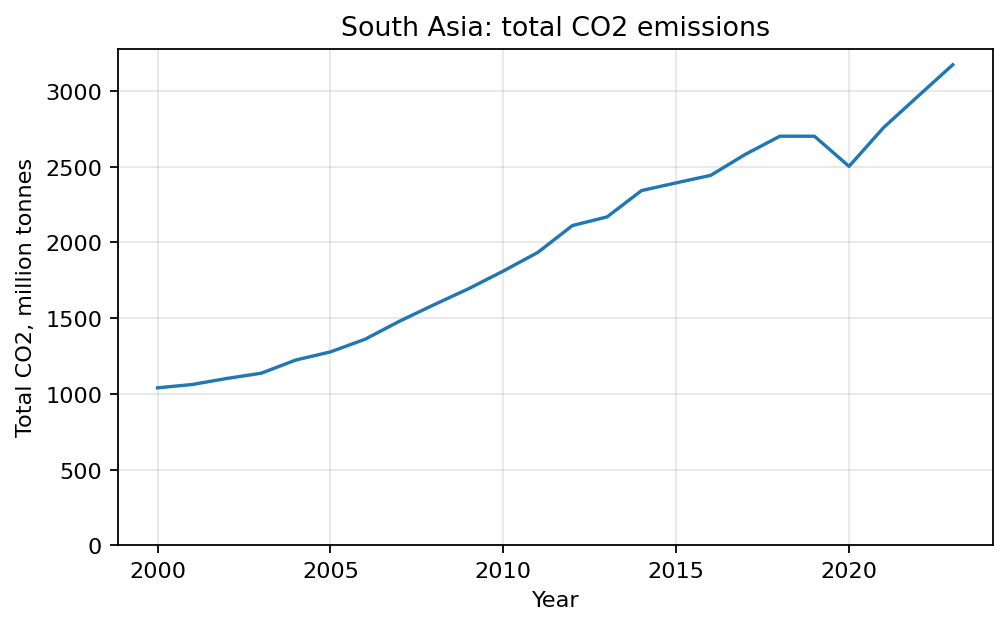

In [91]:
fig = plot_region(panel, "South Asia")

Four decisions in there are worth stating, because they are the difference between a function you can use and one you rewrite every time.

**The data is a parameter.** `plot_region` never mentions `panel`. A function that reaches out for a variable defined somewhere else in the notebook works exactly once - in that notebook, in that order, after that cell has been run. Passing the table in costs one word and makes the function portable.

**It returns `fig`.** In a notebook the figure appears whether you return it or not, so this looks pointless - and it is what lets the caller save it, put it in a report, or change something afterwards. A function that draws and returns nothing is a dead end.

**The parameter goes in the title.** `f"{region}: total CO₂ emissions"` - so that seven figures produced by seven calls are not seven identical-looking pictures you cannot tell apart. If a function takes an argument, that argument belongs in the title.

**It refuses bad input.** `raise ValueError` with a message naming what was wrong, rather than returning an empty chart. An empty chart is the worst possible outcome: it does not look like an error, so it gets used.

In [95]:
# A spelling nobody would notice in an empty figure
try:
    plot_region(panel, "South-Asia")

except ValueError as error:
    print(type(error).__name__, "-", error)

ValueError - no region called 'South-Asia' in this table


And now the thing the function was for:

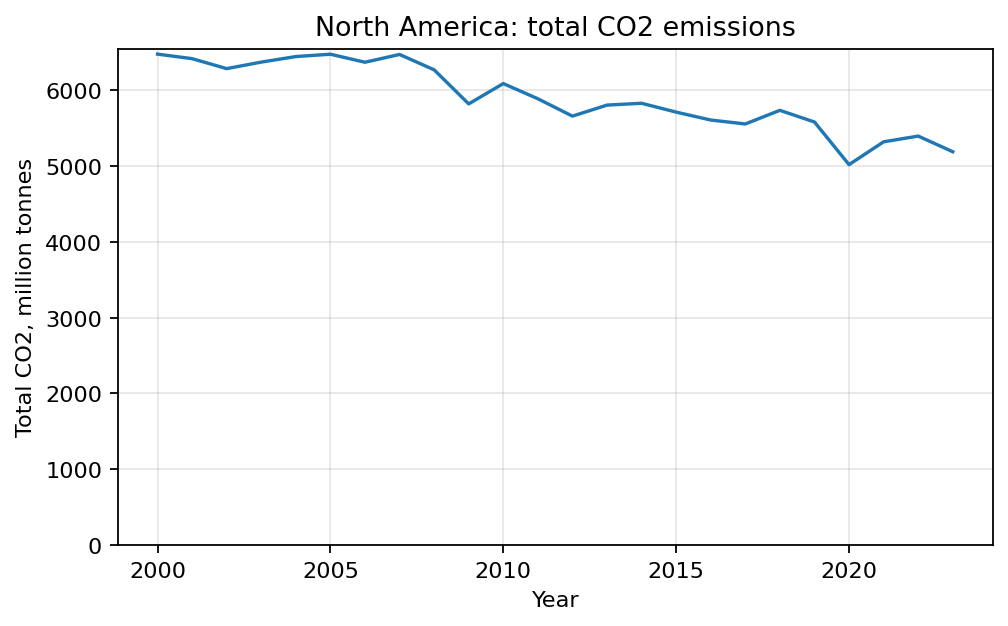

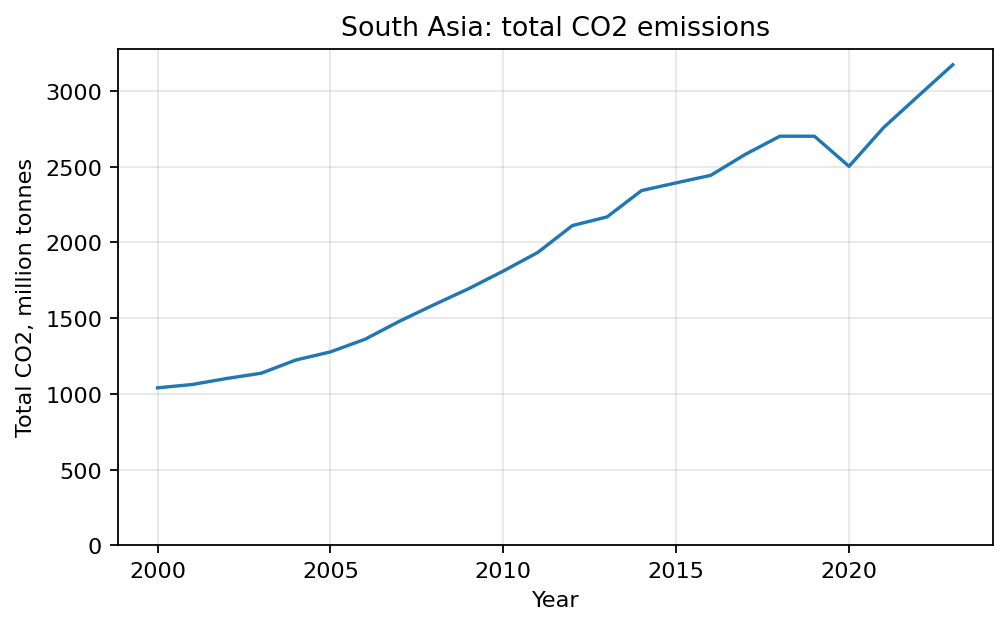

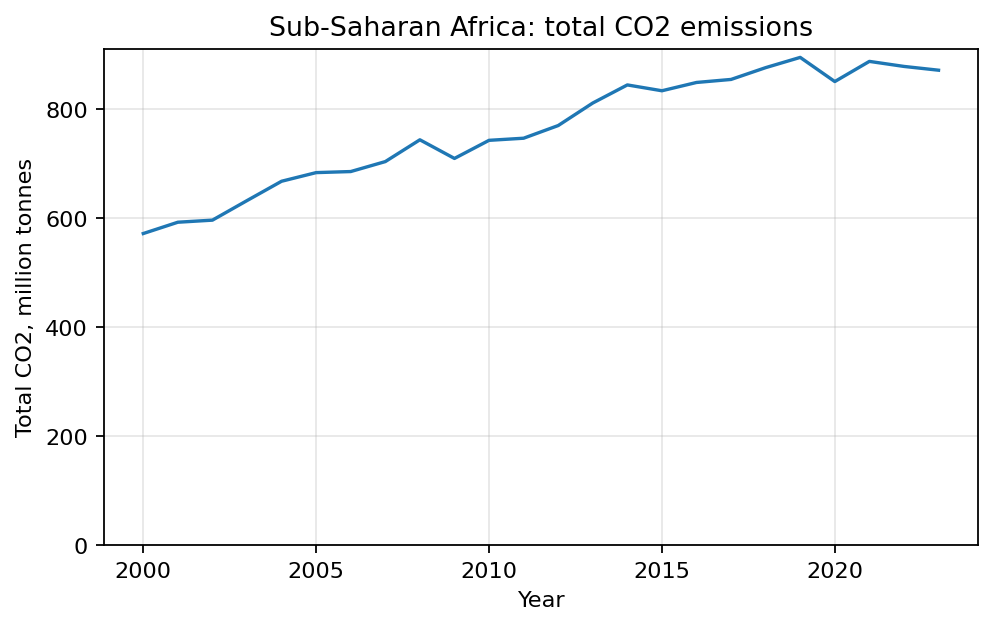

In [98]:
for region in ["North America", "South Asia", "Sub-Saharan Africa"]:
    plot_region(panel, region)

Three figures, two lines, and the seventh region would cost nothing.

> 💡 **Tip:** The moment you copy a plotting cell and change one string in it, write the function. The second copy is where it pays for itself, and the fourth is where doing it by hand starts producing figures that disagree with each other about the axis limits.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Write a plotting function. In a single cell, load the file below and write <code>plot_year(data, year)</code>, which draws a scatter of <code>weight</code> against <code>mpg</code> for the cars of one model year, labels both axes, and puts the year in the title. Give it a docstring, and demonstrate it for 1976.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>cars = pd.read_excel("../data/mpg.xlsx")</code></pre>

</div>

## 7. Saving a figure

A figure that only exists inside a notebook cannot go in a report. `fig.savefig` writes it to a file, and it belongs to `fig` rather than `ax` because it is the whole picture that gets written.

written


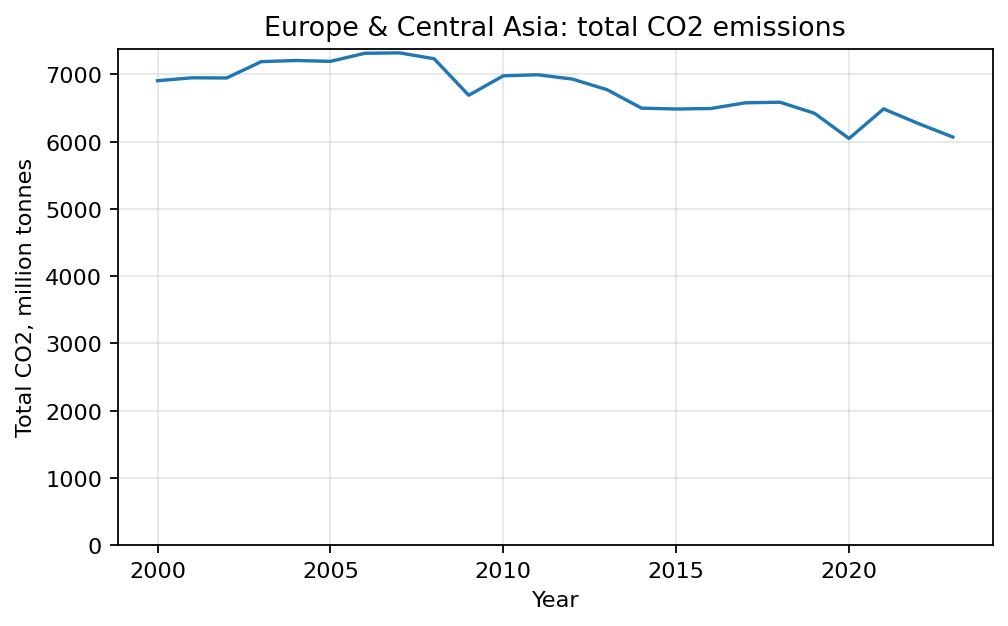

In [99]:
fig = plot_region(panel, "Europe & Central Asia")

fig.savefig("regional-emissions.png", dpi=150, bbox_inches="tight")
print("written")

Three things to know about it.

**The format comes from the file extension.** `.png` gives you a grid of pixels, which is what you want for a slide or a web page. `.pdf` and `.svg` give you a description of the shapes, which stays sharp at any size - use those for anything going into a printed document.

**`dpi` is dots per inch**, and it decides how big the pixel grid is. Combined with `figsize`, which is in inches, it fixes the size of the file: 7 by 4 inches at 150 dpi is 1050 by 600 pixels. 150 is fine for a screen; use at least 300 for print.

**`bbox_inches="tight"`** crops the whitespace around the figure and, more usefully, rescues labels that were running off the edge.


> ⚠️ **Warning:** In a script, `plt.show()` displays the figure and then throws it away, so `fig.savefig` afterwards writes a blank file. **Save first, show second** - or hold on to `fig`, as `plot_region` does, and the order stops mattering.


### Where the file goes, and whether it belongs in git

`fig.savefig("regional-emissions.png", ...)` used a relative path, so the file landed in the notebook's own folder - the same rule as `../data/`, and the same reason it is worth knowing.

The more important point is what kind of file it is. A saved figure is **derived**: the notebook made it, and running the notebook again makes it again. Derived files do not belong in version control. The `.gitignore` in this repository has a line that keeps `.png` files out for exactly that reason, and if you are keeping your own work in git, yours should too.

The rule is the same one from the terminal-and-git session and it is worth repeating in this form: **commit the things you wrote, not the things your code produced.**

## And what a figure is for

We have spent a session on how to draw things. The last few minutes are about whether to.

Every figure is an argument. The table of 203 countries in 2023 is a fact; the bar chart of seven regional means is a claim about it, and so is the histogram, and they say different things. Choosing the chart, sorting the categories, cutting the range into bins, fixing the axis limits, dropping the missing rows - none of those is a neutral act, and all of them were made by you.

So before a figure leaves your screen, three questions.

**What question does it answer?** If you cannot say it in one sentence, the figure is not finished. A chart made because you had the data rather than because you had a question is decoration, and readers can tell.

**Could a reader check it?** Axis labels with units, a title that names the subset, and somewhere a statement of how many rows are in it. If the figure summarizes, say which summary - *mean across countries* is a different chart from *mean across people*, and both are called "average".

**What would it look like if the claim were false?** This is the one that matters most, and this session gave you three cases where the answer is *exactly the same*. Timor-Leste's smooth twelve-year climb was a straight line drawn between two points. The bar for North America was three countries. Two panels side by side made a twentyfold difference look like no difference at all. None of the three produced an error, and none of them looked wrong.

That is the whole reason this session came after the wrangling rather than before it. A figure is the most persuasive thing you can make out of a table, and persuasiveness is not accuracy. Everything you learned about counting rows, checking merges and looking at missing values is what stands between a *convincing* figure and a *true* one.

## Additional resources

- [Quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html) - matplotlib's own introduction, and the *Anatomy of a figure* diagram near the top is worth printing out
- [Axes API](https://matplotlib.org/stable/api/axes_api.html) - the full list of everything `ax` can do, which is where you go when you know what you want and not what it is called
- [Chart visualization](https://pandas.pydata.org/docs/user_guide/visualization.html) - the pandas side, including every `kind=` that `df.plot()` accepts
- [Reshaping and pivot tables](https://pandas.pydata.org/docs/user_guide/reshaping.html) - `pivot`, `melt` and their more powerful relatives
- [SKL401](https://isabelhovdahl.github.io/skl401/) - topic 4 covers the same ground: 4.2 reshaping, 4.3 to 4.6 the four chart types, 4.7 customizing, 4.8 subplots and 4.9 plotting from pandas

**Next week:** putting a line through the scatter plot - linear regression, reading a model's output, and getting a table of results out of Python and into a document.